# 🛡️ Safe RAG: 한국어 금융 문서 임베딩 벡터 역전공격 방어 실험

## 실험 개요
RAG(Retrieval-Augmented Generation) 시스템의 벡터 DB에는 실제 금융 문서의 임베딩이 저장된다.
**Vec2Text** 같은 역전공격(embedding inversion attack)은 이 벡터만으로 원문 텍스트를 상당 수준 복원할 수 있어,
고객 PII(개인식별정보) 유출 위험이 존재한다.

이 노트북은 **한국어 전용** 파이프라인으로 방어 전략의 효과를 실험한다:

```
한국어 문서 생성(≤64토큰) → BGE-m3-ko 임베딩 → 한국어 Vec2Text 역전공격 → PCA/PII 방어 → 재공격 → 트레이드오프 분석
```

| 구성 요소 | 사용 모델 |
|---|---|
| 임베딩 | **dragonkue/BGE-m3-ko** (1024차원, CLS+정규화) |
| 역전공격 | **terriapurplewave/bge-m3-ko-inversion + -corrector** (mt5-base, 20-step 교정) |
| 스코어링 | ROUGE (한국어 어절/음절 토크나이저) |

> ⚠️ BGE-m3-ko vec2text 는 **최대 64토큰**까지만 임베딩·복원한다. 따라서 예시 문서를 64토큰 이내로 생성한다.

| 단계 | 내용 |
|------|------|
| Step 1 | 한국어 PII 데이터셋 생성(≤64토큰) + 임베딩 + FAISS 인덱스 |
| Step 2 | 원본 벡터 역전공격 (공격 기준선 측정) |
| Step 3 | 정규화 벡터 역전공격 |
| Step 4 | PCA 방어 벡터 역전공격 + RAG 트레이드오프 분석 |
| Step 5 | PII-aware 억제 + PCA 복합 방어 |
| Step 6 | 최적 PCA n_components 탐색 |
| Step 7 | Defense-in-Depth 재포지셔닝 |


## 📄 사용 모델 · 라이선스 · 인용 (논문 활용 시 필독)

이 노트북은 공개 허깅페이스 모델을 사용한다. 모두 **허용적(permissive) 라이선스**라 연구·논문에 사용 가능하나, **출처 표기(attribution)** 가 필요하다.

| 아티팩트 | 역할 | 라이선스 | 기반 |
|---|---|---|---|
| `dragonkue/BGE-m3-ko` | 문장 임베딩(1024d, CLS+정규화) | **Apache-2.0** | `BAAI/bge-m3` (MIT) |
| `terriapurplewave/bge-m3-ko-inversion` | 임베딩→1차 복원 | **Apache-2.0** | `google/mt5-base` (Apache-2.0) |
| `terriapurplewave/bge-m3-ko-corrector` | 반복 교정(20-step) | **Apache-2.0** | `google/mt5-base` |
| `vec2text` (라이브러리) | 역전공격 프레임워크 | 저장소 라이선스 확인 | Morris et al. 2023 |

**재현성을 위해 반드시 기록할 것**: HF **commit hash(revision)**, `vec2text==0.0.13` / `transformers==4.44.2` / `sentence-transformers` 버전, 공격 설정(`num_steps=20`, `beam=4`, `max_length=64`), 커스텀 처리(`bge_ko` 임베더 등록, corrector `embedder_dim` 768→1024 수정).

**인용(BibTeX)**
```bibtex
@inproceedings{morris2023text,
  title={Text Embeddings Reveal (Almost) As Much As Text},
  author={Morris, John X. and Kuleshov, Volodymyr and Shmatikov, Vitaly and Rush, Alexander M.},
  booktitle={EMNLP}, year={2023}, eprint={2310.06816}, archivePrefix={arXiv}}
@misc{bge-m3, title={BGE M3-Embedding: Multi-Lingual, Multi-Functionality, Multi-Granularity
  Text Embeddings Through Self-Knowledge Distillation},
  author={Chen, Jianlv and Xiao, Shitao and Zhang, Peitian and Luo, Kun and Lian, Defu and Liu, Zheng},
  year={2024}, eprint={2402.03216}, archivePrefix={arXiv}}
@inproceedings{xue2021mt5, title={mT5: A Massively Multilingual Pre-trained Text-to-Text Transformer},
  author={Xue, Linting and others}, booktitle={NAACL}, year={2021}}
@misc{bgem3ko, author={dragonkue}, title={BGE-m3-ko},
  howpublished={\url{https://huggingface.co/dragonkue/BGE-m3-ko}}, year={2024}}
@misc{bgem3koinv, author={terriapurplewave}, title={BGE-m3-ko Embedding Inversion (inversion + corrector)},
  howpublished={\url{https://huggingface.co/terriapurplewave/bge-m3-ko-corrector}}, year={2025}}
```
> ⚠️ 커뮤니티 모델은 갱신·삭제될 수 있으니 논문에는 사용 시점의 **revision(commit hash)** 을 고정·명시할 것. 실험은 **합성 PII** 만 사용했음을 윤리 섹션에 밝힐 것.


## Step 1. 한국어 금융 문서 임베딩 벡터 생성

### 목적
공격 실험에 사용할 한국어 금융 문서 데이터셋을 준비한다.
역전공격 모델(`bge-m3-ko`)이 **한국어 위키로 학습**되었고 **최대 64토큰**만 처리하므로,
PII 를 포함한 **짧은(≤64토큰) 한국어 문장**을 생성한다.


### 1-0. 환경 설정 (설치 · 임포트 · 모델 로드 통합)

아래 3개 셀에서 **설치 → 공통 임포트/설정 → 모델 로드**를 한 번에 처리한다.
이후 셀들은 여기서 정의한 전역 객체(`bge_embed`, `run_attack`, `corrector`, `ROOT_DIR` 등)를 그대로 사용한다.

- `.env` 의 `OPENAI_API_KEY` 는 **데이터 생성(LLM)에만** 필요하며, 임베딩·공격은 API 없이 로컬 GPU 로 동작한다.
- GPU(CUDA) 환경을 권장한다. 로컬 8GB GPU 는 `ATTACK_BEAM=1`, Colab T4(16GB) 이상은 `ATTACK_BEAM=4` 권장.


In [40]:
# ===== SETUP-A. 패키지 설치 =====
import sys, subprocess

PKGS = [
    "vec2text==0.0.13",
    "sentence-transformers>=2.7",
    "transformers==4.44.2",
    "accelerate>=0.34",
    "sentencepiece",
    "protobuf",
    "faiss-cpu",
    "rouge-score",
    "faker",
    "langchain",
    "langchain-text-splitters",
    "python-dotenv",
    "scikit-learn",
    "matplotlib",
    "pandas",
    "openai",
    "huggingface_hub",
    "safetensors",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *PKGS])
print("✅ SETUP-A: 패키지 설치 완료")


✅ SETUP-A: 패키지 설치 완료


In [41]:
# ===== SETUP-B. 공통 임포트 · 경로 · 설정 =====
import os, sys, json, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import numpy as np
import torch

# --- 루트 디렉토리 (Colab / 로컬 자동 감지) ---
try:
    import google.colab                       # Colab 여부
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT_DIR = "/content/drive/MyDrive/Safe_RAG"
except Exception:
    ROOT_DIR = r"C:\Users\jjh63\Safe_RAG"
sys.path.insert(0, ROOT_DIR)

# --- .env (OpenAI 키: 데이터 생성 LLM 에만 사용) ---
try:
    from dotenv import load_dotenv
    load_dotenv(os.path.join(ROOT_DIR, ".env"))
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- 공격 하이퍼파라미터 (여기서 한 번에 조절) ---
ATTACK_STEPS       = 20     # corrector 교정 step (많을수록 정확·느림)
ATTACK_BEAM        = 1      # 로컬 8GB=1, Colab T4(16GB)+=4 권장
ATTACK_BATCH       = 8      # 역전 배치 크기 (OOM 시 축소)
ATTACK_N_SAMPLES   = 30     # 공격 표본 수 (전체는 오래 걸려 부분표본으로 시연)
MAX_TOKENS         = 64     # BGE-m3-ko vec2text 최대 토큰

print(f"ROOT_DIR = {ROOT_DIR}")
print(f"device   = {device} | torch {torch.__version__}")
print(f"공격 설정: steps={ATTACK_STEPS}, beam={ATTACK_BEAM}, batch={ATTACK_BATCH}, n_samples={ATTACK_N_SAMPLES}")

# --- matplotlib 한글 폰트 설정 (그래프 한글 깨짐 방지) ---
import subprocess
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
def _set_korean_font():
    cands = ["Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic",
             "Noto Sans CJK KR", "Noto Sans KR"]
    avail = {f.name for f in fm.fontManager.ttflist}
    for c in cands:
        if c in avail:
            matplotlib.rcParams["font.family"] = c
            matplotlib.rcParams["axes.unicode_minus"] = False
            return c
    # Colab/Linux: 나눔폰트 설치 시도 후 등록
    try:
        subprocess.run(["apt-get", "-qq", "-y", "install", "fonts-nanum"], check=False)
        for fp in fm.findSystemFonts():
            if "Nanum" in fp:
                fm.fontManager.addfont(fp)
        matplotlib.rcParams["font.family"] = "NanumGothic"
    except Exception:
        pass
    matplotlib.rcParams["axes.unicode_minus"] = False
    return matplotlib.rcParams["font.family"]
print("matplotlib 한글 폰트:", _set_korean_font())


ROOT_DIR = C:\Users\jjh63\Safe_RAG
device   = cuda | torch 2.12.1+cu130
공격 설정: steps=20, beam=1, batch=8, n_samples=30
matplotlib 한글 폰트: Malgun Gothic


In [42]:
# ===== SETUP-C. BGE-m3-ko 임베더 + inversion/corrector 로드 + 헬퍼 정의 =====
import vec2text
from huggingface_hub import snapshot_download
from safetensors.torch import load_file
from sentence_transformers import SentenceTransformer
import vec2text.models.model_utils as _mu
import vec2text.models.inversion as _inv_mod
from vec2text.models import InversionModel, CorrectorEncoderModel
from vec2text.models.config import InversionConfig
import torch.nn as nn

EMBEDDER_REPO = "dragonkue/BGE-m3-ko"

# (1) stock vec2text 에는 없는 "bge_ko" 임베더 키를 등록하는 몽키패치
_emb_cache = {}
def _load_bge_ko():
    if "st" not in _emb_cache:
        _emb_cache["st"] = SentenceTransformer(EMBEDDER_REPO, device=device)  # CLS + L2정규화
    st = _emb_cache["st"]
    return st, st.tokenizer
_orig_loader = _mu.load_embedder_and_tokenizer
def _patched_loader(name, torch_dtype, **kw):
    if name == "bge_ko":
        return _load_bge_ko()
    return _orig_loader(name, torch_dtype, **kw)
_mu.load_embedder_and_tokenizer = _patched_loader
_inv_mod.load_embedder_and_tokenizer = _patched_loader

# (2) 체크포인트 로드 (safetensors 우선, 없으면 bin)
def _load_state(path):
    st = os.path.join(path, "model.safetensors")
    if os.path.exists(st):
        return load_file(st)
    return torch.load(os.path.join(path, "pytorch_model.bin"), map_location="cpu", weights_only=False)

# (3) stock corrector 는 embedder_dim 을 768 로 하드코딩 → BGE(1024)에 맞게 재구성
def _fix_corrector_dim(corr, d):
    if corr.embedder_dim == d:
        return corr
    eh, nr = corr.encoder_hidden_dim, corr.num_repeat_tokens
    for nm in ("embedding_transform_1", "embedding_transform_2", "embedding_transform_3"):
        corr._modules[nm] = nn.Sequential(nn.Linear(d, d), nn.Dropout(0.0), nn.GELU(), nn.Linear(d, eh * nr))
    corr.embedder_dim = d
    return corr

_inv_dir  = snapshot_download("terriapurplewave/bge-m3-ko-inversion")
_corr_dir = snapshot_download("terriapurplewave/bge-m3-ko-corrector")

inv = InversionModel(InversionConfig.from_pretrained(_inv_dir))
inv.load_state_dict(_load_state(_inv_dir), strict=False)
inv = inv.to(device).eval()

corr = CorrectorEncoderModel(InversionConfig.from_pretrained(_corr_dir))
corr = _fix_corrector_dim(corr, inv.embedder_dim)
corr.load_state_dict(_load_state(_corr_dir), strict=False)
corr = corr.to(device).eval()

corrector = vec2text.load_corrector(inv, corr)
EMB_DIM = inv.embedder_dim   # 1024
print(f"✅ 모델 로드 완료 | 임베딩 차원 EMB_DIM={EMB_DIM} | device={device}")

# ---------------- 헬퍼 함수 ----------------
def bge_embed(texts, batch_size=64):
    """텍스트 리스트 → BGE-m3-ko 임베딩 (N, EMB_DIM). 공격/RAG 가 동일 임베딩을 공유한다."""
    if isinstance(texts, str):
        texts = [texts]
    tok = inv.embedder_tokenizer
    out = []
    with torch.no_grad():
        for s in range(0, len(texts), batch_size):
            b = texts[s:s + batch_size]
            enc = tok(b, return_tensors="pt", padding="max_length",
                      truncation=True, max_length=MAX_TOKENS).to(device)
            e = inv.call_embedding_model(input_ids=enc.input_ids, attention_mask=enc.attention_mask)
            out.append(e.cpu().numpy())
    return np.vstack(out).astype(np.float32)

def attack_invert(embeddings, num_steps=None, beam=None, batch=None):
    """임베딩(N, EMB_DIM) → 복원 텍스트 리스트. inversion + corrector 20-step."""
    num_steps = ATTACK_STEPS if num_steps is None else num_steps
    beam      = ATTACK_BEAM  if beam is None else beam
    batch     = ATTACK_BATCH if batch is None else batch
    emb = np.asarray(embeddings, dtype=np.float32)
    res = []
    for s in range(0, len(emb), batch):
        eb = torch.tensor(emb[s:s + batch], dtype=torch.float32, device=device)
        res += vec2text.invert_embeddings(embeddings=eb, corrector=corrector,
                                          num_steps=num_steps, sequence_beam_width=beam)
    return res

# ---------------- 한국어 ROUGE ----------------
from rouge_score import rouge_scorer
class _KoTok:
    """기본 rouge_score 는 비-ASCII 를 삭제 → 한국어가 사라진다. 어절/음절 토크나이저로 교체."""
    def __init__(self, mode): self.mode = mode
    def tokenize(self, t):
        return t.split() if self.mode == "word" else list(t.replace(" ", "").replace("\n", ""))
_rouge_w = rouge_scorer.RougeScorer(["rouge1", "rougeL"], tokenizer=_KoTok("word"))
_rouge_c = rouge_scorer.RougeScorer(["rouge1", "rougeL"], tokenizer=_KoTok("char"))
def ko_rouge1(ref, hyp, mode="char"):
    sc = (_rouge_c if mode == "char" else _rouge_w).score(ref, hyp)
    return sc["rouge1"].fmeasure

def run_attack(embeddings, refs, label="", n=None, show=8, mode="char", verbose=True):
    """공격 실행 + 요청 형식(원본/복원/ROUGE) 출력. (scores, hypotheses) 반환."""
    n = ATTACK_N_SAMPLES if n is None else n
    n = min(n, len(embeddings), len(refs))
    emb, refs = np.asarray(embeddings)[:n], list(refs)[:n]
    t0 = time.time()
    hyps = attack_invert(emb)
    scores = [ko_rouge1(r, h, mode) for r, h in zip(refs, hyps)]
    if verbose:
        print("=" * 100)
        print(f"[{label}] 역전공격 결과  (n={n}, steps={ATTACK_STEPS}, beam={ATTACK_BEAM}, {time.time()-t0:.1f}s)")
        print("=" * 100)
        for i in range(min(show, n)):
            print(f"[{i+1}] 원본: {refs[i][:50].strip()}")
            print(f"    복원: {hyps[i][:50].strip()}")
            print(f"    ROUGE 스코어: 음절-1 {ko_rouge1(refs[i],hyps[i],'char'):.4f} | 어절-1 {ko_rouge1(refs[i],hyps[i],'word'):.4f}")
        print("-" * 100)
        print(f"평균 ROUGE-1({mode}): {np.mean(scores):.4f} | 중앙값 {np.median(scores):.4f} | 최대 {np.max(scores):.4f}")
    return scores, hyps

# 기존 노트북 호환용 별칭 (이후 셀들이 get_embedding 을 호출)
def get_embedding(text):
    return bge_embed([text])[0]

import faiss
def eval_recall5(emb, n_eval=50):
    """자기검색 Recall@5 (검색 유용성 지표). 모든 방어 셀에서 공용 사용."""
    n_eval = min(n_eval, len(emb))
    e = np.asarray(emb)[:n_eval].copy().astype(np.float32); faiss.normalize_L2(e)
    idx = faiss.IndexFlatIP(e.shape[1]); idx.add(e)
    return sum(1 for i in range(n_eval) if i in idx.search(e[i:i+1], 5)[1][0]) / n_eval

print("✅ SETUP-C: bge_embed / attack_invert / run_attack / ko_rouge1 준비 완료")


Fetching 10 files: 100%|██████████| 10/10 [00:00<?, ?it/s]


✅ 모델 로드 완료 | 임베딩 차원 EMB_DIM=1024 | device=cuda
✅ SETUP-C: bge_embed / attack_invert / run_attack / ko_rouge1 준비 완료


In [43]:
# ===== 성능 지표 확장: PII exact-match 복원율("하면 안 되는 말" 누출 측정) =====
# ROUGE 는 표면 단어 겹침만 본다. 프라이버시 공격의 본질은 "특정 PII(이름/계좌/전화/이메일 등)가
# 그대로 복원되었는가" 이다. 이를 canary/exact-match extraction 관점의 PII 누출률로 측정한다.
import re as _re

def _digits(s):
    return _re.sub(r"\D", "", str(s))

def extract_pii_values(doc):
    """생성 데이터의 pii_spans 에서 (타입, 값) 목록."""
    out = []
    for sp in doc.get("pii_spans", []):
        v = str(sp.get("value", "")).strip()
        if v:
            out.append((sp.get("type", "PII"), v))
    return out

def pii_recovery(hyps, docs, refs=None, min_digits=4):
    """복원문(hyps)에 실제 PII 값이 나타났는지 측정.
    - strict : 문자열 그대로 포함
    - digit  : 숫자형 PII 는 숫자만 비교(부분 복원 관대 평가, min_digits 이상)
    - refs 가 주어지면 '모델이 실제 본(64토큰) 원문'에 존재하는 PII 만 대상에 포함.
    반환: dict(strict_rate, digit_rate, doc_leak_rate, by_type={type:[hit,total]}, total)
    """
    n = min(len(hyps), len(docs))
    tot = hit_s = hit_d = doc_leak = 0
    by_type = {}
    for i in range(n):
        h = hyps[i]; hd = _digits(h); ref = refs[i] if refs is not None else None
        leaked = False
        for typ, v in extract_pii_values(docs[i]):
            if ref is not None and (v not in ref and (not _digits(v) or _digits(v) not in _digits(ref))):
                continue  # 모델이 못 본 PII 는 제외
            tot += 1
            bt = by_type.setdefault(typ, [0, 0]); bt[1] += 1
            s_hit = v in h
            d_hit = bool(_digits(v)) and len(_digits(v)) >= min_digits and _digits(v) in hd
            if s_hit: hit_s += 1; bt[0] += 1
            if s_hit or d_hit: hit_d += 1; leaked = True
        if leaked: doc_leak += 1
    return {"strict_rate": hit_s / tot if tot else 0.0,
            "digit_rate":  hit_d / tot if tot else 0.0,
            "doc_leak_rate": doc_leak / n if n else 0.0,
            "by_type": by_type, "total": tot, "n_docs": n}

def print_pii_report(hyps, docs, refs=None, label=""):
    r = pii_recovery(hyps, docs, refs)
    print(f"[{label}] PII 누출 지표 (대상 PII {r['total']}개 / 문서 {r['n_docs']}개)")
    print(f"  · PII exact-match 복원율(strict) : {r['strict_rate']:.1%}")
    print(f"  · 숫자 관대 복원율(digit)        : {r['digit_rate']:.1%}")
    print(f"  · 문서당 1개 이상 누출 비율      : {r['doc_leak_rate']:.1%}")
    if r["by_type"]:
        detail = " | ".join(f"{t}: {v[0]}/{v[1]}" for t, v in sorted(r["by_type"].items()))
        print(f"  · 타입별(strict) : {detail}")
    return r

print("✅ PII 누출 지표 준비: pii_recovery(), print_pii_report()")


✅ PII 누출 지표 준비: pii_recovery(), print_pii_report()


### 📐 측정 도구모음 (Multi-angle Measurement Toolkit)

ROUGE·PII exact-match·Recall@5(포화)만으로는 부족하다. 방어를 **다각도 + 신뢰구간**으로 측정한다.

**프라이버시(공격)**: 퍼지 PII 복원율(이름 편집거리·계좌 부분숫자) · **worst-case**(p95/max) · **의미 누출**(복원문 재임베딩 코사인)
**유용성(검색)**: 랭킹 스위트(Recall@1/5/10·MRR·nDCG, 질의=redacted→원문) · **이웃 보존도**(Jaccard@k·Spearman)
**통계**: 모든 per-item 지표에 **부트스트랩 95% CI**
→ 중앙 `evaluate_defense()` 가 방어당 공격 1회로 위 전부를 계산.


In [ ]:
# ===== 측정 도구모음 (Multi-angle Measurement Toolkit) =====
import difflib

def _unit_rows(E):
    E = np.asarray(E, dtype=np.float32)
    return E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)

# ---------- 프라이버시 ----------
def pii_recovery_fuzzy(hyps, docs, refs=None, name_ratio=0.8, min_digits=4):
    """strict(정확일치) + fuzzy(이름 편집거리·숫자 부분일치) + 문서별 복원율(per_doc)."""
    n = min(len(hyps), len(docs)); tot = s_hit = f_hit = doc_leak = 0
    by_type = {}; per_doc = []
    for i in range(n):
        h = hyps[i]; hd = _digits(h); ref = refs[i] if refs is not None else None
        d_tot = d_hit = 0
        for typ, v in extract_pii_values(docs[i]):
            if ref is not None and v not in ref and (not _digits(v) or _digits(v) not in _digits(ref)):
                continue
            tot += 1; d_tot += 1; bt = by_type.setdefault(typ, [0, 0]); bt[1] += 1
            strict = v in h
            if _digits(v):
                fuzzy = strict or (len(_digits(v)) >= min_digits and _digits(v) in hd)
            else:
                fuzzy = strict or (len(v) >= 2 and difflib.SequenceMatcher(None, v, h).ratio() >= name_ratio)
            if strict: s_hit += 1
            if fuzzy: f_hit += 1; bt[0] += 1; d_hit += 1
        if d_tot: per_doc.append(d_hit / d_tot)
        if d_hit: doc_leak += 1
    per_doc = np.array(per_doc) if per_doc else np.zeros(1)
    return {"strict": s_hit / tot if tot else 0.0, "fuzzy": f_hit / tot if tot else 0.0,
            "per_doc": per_doc, "by_type": by_type, "doc_leak": doc_leak / n if n else 0.0, "total": tot}

def semantic_leakage(hyps, refs):
    """복원문 재임베딩 vs 원문 임베딩 코사인 (글자 안맞아도 의미가 새는가)."""
    H = _unit_rows(bge_embed(list(hyps))); R = _unit_rows(bge_embed(list(refs)))
    per = np.sum(H * R, axis=1)
    return {"per_item": per, "mean": float(per.mean())}

# ---------- 유용성 ----------
def ranking_metrics(emb_index, emb_query):
    """질의(redacted)로 원문(index) 검색. 정답=같은 index. per-query rank/nDCG 반환."""
    X = _unit_rows(emb_index); Q = _unit_rows(emb_query)
    n = min(len(X), len(Q)); X, Q = X[:n], Q[:n]
    S = Q @ X.T
    order = np.argsort(-S, axis=1)
    ranks = np.array([int(np.where(order[i] == i)[0][0]) for i in range(n)])
    ndcg = np.array([1.0 / np.log2(r + 2) if r < 10 else 0.0 for r in ranks])  # 단일 정답: IDCG=1
    return {"ranks": ranks, "ndcg": ndcg}

def _spearman(a, b):
    ra = np.argsort(np.argsort(a)).astype(float); rb = np.argsort(np.argsort(b)).astype(float)
    ra -= ra.mean(); rb -= rb.mean()
    return float((ra @ rb) / (np.sqrt((ra @ ra) * (rb @ rb)) + 1e-12))

def neighbor_preservation(emb_raw, emb_def, k=10):
    """원본 대비 방어후 이웃구조 보존: top-k Jaccard + 유사도행렬 Spearman."""
    def sim(E):
        E = _unit_rows(E); return E @ E.T
    Sr, Sd = sim(emb_raw), sim(emb_def)
    def topk(S):
        Sf = S.copy(); np.fill_diagonal(Sf, -np.inf); return np.argsort(-Sf, axis=1)[:, :k]
    A, B = topk(Sr), topk(Sd)
    jac = np.mean([len(set(A[i]) & set(B[i])) / max(len(set(A[i]) | set(B[i])), 1) for i in range(len(A))])
    iu = np.triu_indices(len(Sr), k=1)
    return {"jaccard": float(jac), "spearman": _spearman(Sr[iu], Sd[iu])}

# ---------- 통계 ----------
def bootstrap_ci(arr, n_boot=1000, alpha=0.05, seed=0):
    a = np.asarray(arr, dtype=float)
    if len(a) == 0: return (0.0, 0.0, 0.0)
    rng = np.random.default_rng(seed)
    means = a[rng.integers(0, len(a), size=(n_boot, len(a)))].mean(axis=1)
    lo, hi = np.percentile(means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return (float(a.mean()), float(lo), float(hi))

# ---------- 중앙 집계기 ----------
def evaluate_defense(name, emb_def, *, emb_raw, refs, docs, emb_qdef, attack_n=None):
    """방어당 공격 1회로 프라이버시·유용성·통계 전 지표 계산. 각 지표=(point,lo,hi) 또는 scalar."""
    emb_def = np.asarray(emb_def, dtype=np.float32)
    n = attack_n or ATTACK_N_SAMPLES
    n = min(n, len(emb_def), len(refs), len(docs))
    hyps = attack_invert(emb_def[:n])
    rouge = np.array([ko_rouge1(refs[i], hyps[i]) for i in range(n)])
    pr = pii_recovery_fuzzy(hyps, docs[:n], refs[:n])
    sem = semantic_leakage(hyps, refs[:n])["per_item"]
    rk = ranking_metrics(emb_def, emb_qdef)
    npv = neighbor_preservation(emb_raw, emb_def)
    R = bootstrap_ci
    return {
        "name": name,
        "rouge":  R(rouge),
        "pii":    R(pr["per_doc"]),                 # 문서별 퍼지 PII 복원율(+CI)
        "pii_strict": pr["strict"],
        "pii_p95": float(np.percentile(pr["per_doc"], 95)),
        "pii_max": float(pr["per_doc"].max()),
        "semantic": R(sem),
        "R@1":  R((rk["ranks"] < 1).astype(float)),
        "R@5":  R((rk["ranks"] < 5).astype(float)),
        "R@10": R((rk["ranks"] < 10).astype(float)),
        "MRR":  R(1.0 / (rk["ranks"] + 1)),
        "nDCG": R(rk["ndcg"]),
        "jaccard": npv["jaccard"], "spearman": npv["spearman"],
    }

print("✅ 측정 도구모음: pii_recovery_fuzzy / semantic_leakage / ranking_metrics / "
      "neighbor_preservation / bootstrap_ci / evaluate_defense 준비 완료")


### 1-1. 예시 한국어 PII 데이터셋 생성 (≤64토큰)

**목적**: BGE-m3-ko vec2text 의 64토큰 제한에 맞춰, PII 를 포함한 **짧은 한국어 금융 문장**을 생성한다.

- `OPENAI_API_KEY` 가 있으면 **gpt-4o-mini** 로 자연스러운 한 문장을 생성하고, 없거나 실패하면 **템플릿**으로 폴백한다.
- 각 문서는 `BGE-m3-ko` 토크나이저 기준 **64토큰 이내**임을 코드로 검증한다.
- 이름은 항상 포함하고, 계좌번호·전화·이메일 등 PII 2~3개만 넣어 문장을 짧게 유지한다.


In [44]:
# ===== 예시 한국어 PII 문서 생성 (<=64토큰) =====
# 기존 generate_korean_pii_dataset.py 의 (수정된) 생성 함수를 사용한다.
import json, importlib
from faker import Faker

N_DOCS      = 300                       # 생성 문서 수
DATASET_PATH = os.path.join(ROOT_DIR, "output", "kor_financial_pii_dataset_64tok.jsonl")
os.makedirs(os.path.dirname(DATASET_PATH), exist_ok=True)

# 수정된 생성기 로드 (LLM 짧은 문장 + 템플릿 폴백)
import generate_korean_pii_dataset as gk
importlib.reload(gk)
fake = Faker('ko-KR')  # 한국어 이름(예: 김하은) 포함 PII 생성

USE_LLM = bool(os.environ.get("OPENAI_API_KEY"))
print(f"생성기: {'gpt-4o-mini (LLM)' if USE_LLM else '템플릿(오프라인)'} | 목표 {N_DOCS}개, <= {MAX_TOKENS}토큰")

docs = []
with open(DATASET_PATH, "w", encoding="utf-8") as f:
    for i in range(N_DOCS):
        doc = gk.generate_korean_document(fake, i, use_llm=USE_LLM, max_tokens=MAX_TOKENS)
        docs.append(doc)
        f.write(json.dumps(doc, ensure_ascii=False, default=str) + "\n")
        if (i + 1) % 50 == 0:
            print(f"  생성 {i+1}/{N_DOCS}")

# 토큰 길이 검증
tok = inv.embedder_tokenizer
tlen = np.array([len(tok.encode(d["text"])) for d in docs])
print(f"\n✅ 생성 완료: {len(docs)}개 → {DATASET_PATH}")
print(f"   토큰 길이  평균 {tlen.mean():.1f} | 최대 {tlen.max()} | >64토큰 비율 {100*(tlen>MAX_TOKENS).mean():.1f}%")
print("\n[샘플 3개]")
for d in docs[:3]:
    print(f"  - ({d['doc_type']}) {d['text'][:60]}")


생성기: gpt-4o-mini (LLM) | 목표 300개, <= 64토큰


KeyboardInterrupt: 

### 1-2. 문서 로드 및 청크 구성

BGE-m3-ko 는 64토큰까지만 처리하고 예시 문서가 이미 ≤64토큰이므로 **1문서 = 1청크**로 둔다.
(긴 문서를 잘게 쪼개던 기존 `RecursiveCharacterTextSplitter` 는 더 이상 필요 없다.)


In [45]:
# ===== 문서 로드 → 1문서=1청크 =====
class Chunk:
    """간단한 청크 래퍼 (LangChain Document 호환: .page_content)."""
    def __init__(self, text, meta=None):
        self.page_content = text
        self.metadata = meta or {}

documents = []
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        documents.append(r)

# 각 문서를 64토큰 이내로 보장(초과 시 잘라서 청크화)
tok = inv.embedder_tokenizer
chunks = []
for r in documents:
    ids = tok.encode(r["text"], add_special_tokens=False)[:MAX_TOKENS]
    text = tok.decode(ids, skip_special_tokens=True)
    chunks.append(Chunk(text, {"doc_id": r["doc_id"], "doc_type": r["doc_type"]}))

chunk_texts = [c.page_content for c in chunks]
print(f"총 청크 수: {len(chunks)} (1문서=1청크)")
print(f"예시: {chunk_texts[0][:60]}")


총 청크 수: 1 (1문서=1청크)
예시: 이경자 고객님, 계좌폐지요청서는 전화 010-1409-5506로 문의해 주시기 바랍니다.


### 1-3. 임베딩 생성 및 FAISS 인덱스 구축

각 청크를 **BGE-m3-ko**로 **1024차원** 벡터로 변환하고 FAISS `IndexFlatIP`에 저장한다.
BGE-m3-ko 임베딩은 이미 CLS+L2정규화된 단위벡터라, 원본 벡터와 정규화 벡터가 사실상 동일하다.

- `embeddings_unsafe_raw.npy`: 원본 벡터 (공격 실험용, 1024d)
- `faiss_unsafe.index`: FAISS 인덱스 (RAG 검색용)

> 공격과 RAG 가 **동일한 `bge_embed`** 를 사용하므로, 역전공격이 실제 저장 벡터를 그대로 공략한다.


In [46]:
# ===== 임베딩 + FAISS 인덱스 =====
import faiss

embeddings_raw = bge_embed(chunk_texts)            # (N, 1024) 단위벡터
raw_path   = os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy")
index_path = os.path.join(ROOT_DIR, "faiss_unsafe.index")
np.save(raw_path, embeddings_raw)
print(f"원본 벡터 저장: {raw_path} | shape {embeddings_raw.shape}")

emb_norm = embeddings_raw.copy()
faiss.normalize_L2(emb_norm)
index = faiss.IndexFlatIP(EMB_DIM)
index.add(emb_norm)
faiss.write_index(index, index_path)
print(f"FAISS 인덱스 저장: {index_path} | {index.ntotal}개 벡터 (dim={EMB_DIM})")


원본 벡터 저장: C:\Users\jjh63\Safe_RAG\embeddings_unsafe_raw.npy | shape (1, 1024)
FAISS 인덱스 저장: C:\Users\jjh63\Safe_RAG\faiss_unsafe.index | 1개 벡터 (dim=1024)


### 1-4. RAG 기본 성능 측정 (Recall@K)

방어 적용 전 기준 RAG 성능을 측정한다. 각 청크를 쿼리로 넣어 동일 청크가 상위 K개 안에 오는 비율.


In [47]:
# ===== Recall@K =====
def recall_at_k(index_path, chunk_texts, k=5, n_eval=20):
    index = faiss.read_index(index_path)
    n_eval = min(n_eval, len(chunk_texts))
    hits = 0
    for i in range(n_eval):
        vec = bge_embed([chunk_texts[i]]).copy()
        faiss.normalize_L2(vec)
        _, idxs = index.search(vec, k)
        if i in idxs[0]:
            hits += 1
    score = hits / n_eval
    print(f"Recall@{k} ({os.path.basename(index_path)}): {score:.2f}")
    return score

recall_at_k(index_path, chunk_texts, k=5, n_eval=20)  # 목표 0.90 이상


Recall@5 (faiss_unsafe.index): 1.00


1.0

### 1-5. FAISS 인덱스에서 정규화 벡터 추출

FAISS 내부의 L2 정규화 벡터를 numpy 로 복원한다. (BGE 임베딩은 이미 단위벡터라 원본과 방향·크기 모두 동일)


In [48]:
# ===== 정규화 벡터 추출 =====
index = faiss.read_index(index_path)
n, dim = index.ntotal, index.d
embeddings_norm = np.zeros((n, dim), dtype=np.float32)
index.reconstruct_n(0, n, embeddings_norm)
print(f"추출된 정규화 벡터: {embeddings_norm.shape}")


추출된 정규화 벡터: (1, 1024)


### 1-6. 임베딩 유틸 함수

이후 단계에서 새로운 텍스트를 임베딩할 때 쓰는 공통 함수는 **SETUP-C** 의 `bge_embed`(및 `get_embedding` 별칭)를 그대로 사용한다.


In [49]:
# get_embedding / bge_embed 는 SETUP-C 에서 이미 정의됨. 동작 확인만.
_v = get_embedding("테스트 문장입니다.")
print(f"get_embedding 출력 차원: {_v.shape}  (기대: ({EMB_DIM},))")


get_embedding 출력 차원: (1024,)  (기대: (1024,))


### 1-7. PCA 방어 벡터 생성 (1차 시도, n=128)

원본 1024차원 벡터를 128차원으로 압축 후 역투영(reconstruct)한다.
하위 주성분 정보가 손실되며 역전공격에 필요한 세부 패턴이 제거된다.

```
원본 (1024d) → PCA 압축 (128d) → 역투영 (1024d) → L2정규화 → 방어 벡터
```


In [50]:
# ===== PCA 방어 벡터 (n=128) =====
from sklearn.decomposition import PCA

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
n_samples, n_features = embeddings_raw.shape
n_components = min(128, n_samples - 1, n_features)
print(f"PCA 설정: {n_features}d → {n_components}d → {n_features}d")

pca = PCA(n_components=n_components, svd_solver="full").fit(embeddings_raw)
reconstructed = pca.inverse_transform(pca.transform(embeddings_raw)).astype(np.float32)
norms = np.linalg.norm(reconstructed, axis=1, keepdims=True)
embeddings_pca = (reconstructed / norms).astype(np.float32)   # 단위벡터로 맞춤
np.save(os.path.join(ROOT_DIR, "embeddings_defense_pca.npy"), embeddings_pca)
print(f"PCA 방어 벡터 저장 | 보존 분산 {pca.explained_variance_ratio_.sum():.1%}")


PCA 설정: 1024d → 0d → 1024d
PCA 방어 벡터 저장 | 보존 분산 0.0%


## Step 2. 원본 벡터로 Vec2Text 역전공격

BGE-m3-ko 원본 1024차원 벡터에 직접 한국어 Vec2Text 를 적용한다. 이 결과가 **공격 기준선**이다.

- 지표: **ROUGE-1**(음절/어절). 높을수록 공격 성공.


In [51]:
# ===== Step 2. 원본 벡터 역전공격 (기준선) =====
embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
refs = chunk_texts

scores_raw, hypotheses_raw = run_attack(embeddings_raw, refs, label="원본 벡터", n=ATTACK_N_SAMPLES)


[원본 벡터] 역전공격 결과  (n=1, steps=20, beam=1, 11.2s)
[1] 원본: 이경자 고객님, 계좌폐지요청서는 전화 010-1409-5506로 문의해 주시기 바랍니다.
    복원: 폐지문의는 이경자금융조합사무소, 한글번호 0105-64-596이다.
    ROUGE 스코어: 음절-1 0.5526 | 어절-1 0.0000
----------------------------------------------------------------------------------------------------
평균 ROUGE-1(char): 0.5526 | 중앙값 0.5526 | 최대 0.5526


### 📊 성능 지표 확장 — PII 복원율("하면 안 되는 말" 누출)

ROUGE(표면 겹침)만으로는 **실제 개인정보가 복원됐는지** 알 수 없다.
여기서는 각 문서의 실제 PII 값(이름·계좌번호·전화·이메일·주민번호 등)이 복원문에 그대로 나타났는지를
**PII exact-match 복원율(누출률)** 로 측정한다. 이 값이 0에 가까울수록 방어가 성공한 것이다.


In [52]:
# ===== Step 2 기준선의 PII 누출 측정 =====
# documents[i] 의 pii_spans 가 chunks[i] 와 정렬됨. 공격 표본(앞 n개)에 대해 측정.
_n = len(hypotheses_raw)
refs_seen = chunk_texts[:_n]
docs_seen = documents[:_n]
print_pii_report(hypotheses_raw, docs_seen, refs_seen, label="원본 벡터(기준선)")


[원본 벡터(기준선)] PII 누출 지표 (대상 PII 2개 / 문서 1개)
  · PII exact-match 복원율(strict) : 50.0%
  · 숫자 관대 복원율(digit)        : 50.0%
  · 문서당 1개 이상 누출 비율      : 100.0%
  · 타입별(strict) : PERSON_NAME: 1/1 | PHONE: 0/1


{'strict_rate': 0.5,
 'digit_rate': 0.5,
 'doc_leak_rate': 1.0,
 'by_type': {'PERSON_NAME': [1, 1], 'PHONE': [0, 1]},
 'total': 2,
 'n_docs': 1}

## Step 3. 정규화 벡터로 Vec2Text 역전공격

FAISS 내부 정규화 벡터에 공격한다. BGE 임베딩은 원래 단위벡터라, 정규화가 방어 효과를 갖지 못함을 확인한다.
(→ 원본과 ROUGE 가 사실상 동일하게 나올 것으로 예상)


In [53]:
# ===== Step 3. 정규화 벡터 역전공격 =====
scores_norm, hypotheses_norm = run_attack(embeddings_norm, chunk_texts, label="정규화 벡터", n=ATTACK_N_SAMPLES)
print(f"\n원본 평균 {np.mean(scores_raw):.4f} vs 정규화 평균 {np.mean(scores_norm):.4f} → 정규화만으로는 방어 효과 거의 없음")


[정규화 벡터] 역전공격 결과  (n=1, steps=20, beam=1, 11.1s)
[1] 원본: 이경자 고객님, 계좌폐지요청서는 전화 010-1409-5506로 문의해 주시기 바랍니다.
    복원: 폐지문의는 이경자금융조합사무소, 한글번호 0105-64-596이다.
    ROUGE 스코어: 음절-1 0.5526 | 어절-1 0.0000
----------------------------------------------------------------------------------------------------
평균 ROUGE-1(char): 0.5526 | 중앙값 0.5526 | 최대 0.5526

원본 평균 0.5526 vs 정규화 평균 0.5526 → 정규화만으로는 방어 효과 거의 없음


## Step 4-A. PCA 방어 벡터의 역전공격 방어 성능 측정

128차원 압축 후 역투영한 PCA 방어 벡터가 공격을 얼마나 막는지 측정한다.


In [55]:
# ===== Step 4-A. PCA 방어 벡터 역전공격 =====
embeddings_pca = np.load(os.path.join(ROOT_DIR, "embeddings_defense_pca.npy"))
scores_pca, hypotheses_pca = run_attack(embeddings_pca, chunk_texts, label="PCA 방어 벡터", n=ATTACK_N_SAMPLES)

red = (np.mean(scores_raw) - np.mean(scores_pca)) / max(np.mean(scores_raw), 1e-9) * 100
print(f"\n공격 성공률 감소(PCA): {np.mean(scores_raw):.4f} → {np.mean(scores_pca):.4f}  ({red:.1f}% 감소)")


[PCA 방어 벡터] 역전공격 결과  (n=1, steps=20, beam=1, 11.1s)
[1] 원본: 이경자 고객님, 계좌폐지요청서는 전화 010-1409-5506로 문의해 주시기 바랍니다.
    복원: 폐지문의는 이경자금융조합사무소, 한글번호 0105-64-596이다.
    ROUGE 스코어: 음절-1 0.5526 | 어절-1 0.0000
----------------------------------------------------------------------------------------------------
평균 ROUGE-1(char): 0.5526 | 중앙값 0.5526 | 최대 0.5526

공격 성공률 감소(PCA): 0.5526 → 0.5526  (0.0% 감소)


## Step 4-B. RAG 검색 정확성 vs 방어 성능 트레이드오프 분석

방어가 강해질수록 RAG 성능이 얼마나 희생되는지 정량화한다.

| 지표 | 의미 | 목표 |
|------|------|------|
| Recall@5 | 정답 청크가 상위 5개 안에 있을 확률 | ≥ 90% |
| ROUGE-1 감소율 | 공격 성공률이 얼마나 줄었는가 | > 20% |


In [56]:
# ===== Step 4-B. 트레이드오프 분석 =====
print("=" * 80); print("📊 트레이드오프: RAG 정확성 vs 벡터 보안"); print("=" * 80)

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
embeddings_pca = np.load(os.path.join(ROOT_DIR, "embeddings_defense_pca.npy"))

attack_results = {
    "원본 벡터":    {"rouge_mean": np.mean(scores_raw),  "rouge_std": np.std(scores_raw)},
    "정규화 벡터":  {"rouge_mean": np.mean(scores_norm), "rouge_std": np.std(scores_norm)},
    "PCA 방어 벡터": {"rouge_mean": np.mean(scores_pca),  "rouge_std": np.std(scores_pca)},
}
print("\n🔴 역전공격 성공도 (ROUGE-1):"); print("-" * 80)
for name, m in attack_results.items():
    print(f"{name:16} | 평균 {m['rouge_mean']:.3f} ± {m['rouge_std']:.3f}")

def evaluate_rag_recall(embeddings, chunk_texts, k=5, n_eval=50):
    n_eval = min(n_eval, len(embeddings))
    e = embeddings[:n_eval].copy(); faiss.normalize_L2(e)
    idx = faiss.IndexFlatIP(embeddings.shape[1]); idx.add(e)
    hits = sum(1 for i in range(n_eval) if i in idx.search(e[i:i+1], k)[1][0])
    return hits / n_eval

print("\n🟢 RAG 검색 정확성 (Recall@5):"); print("-" * 80)
rag_results = {}
for emb, name in [(embeddings_raw, "원본 벡터"), (embeddings_pca, "PCA 방어 벡터")]:
    r = evaluate_rag_recall(emb, chunk_texts, 5, 50)
    rag_results[name] = r
    print(f"{name:16} | Recall@5: {r:.1%}")

raw_a, pca_a = attack_results["원본 벡터"]["rouge_mean"], attack_results["PCA 방어 벡터"]["rouge_mean"]
attack_reduction = (raw_a - pca_a) / max(raw_a, 1e-9) * 100
raw_r, pca_r = rag_results["원본 벡터"], rag_results["PCA 방어 벡터"]
recall_loss = (raw_r - pca_r) / max(raw_r, 1e-9) * 100
print("\n" + "=" * 80)
print(f"공격 성공률 감소: {attack_reduction:.1f}%   |   RAG 정확성 손실: {recall_loss:.1f}%")
if pca_r >= 0.90 and attack_reduction > 20:
    print("✅ 최적 트레이드오프 달성")
elif pca_r >= 0.90:
    print("⚠️ RAG 성능 충분하나 방어력 개선 필요 (n_components ↓)")
else:
    print("⚠️ RAG 성능 목표 미달 (n_components ↑)")
print("=" * 80)


📊 트레이드오프: RAG 정확성 vs 벡터 보안

🔴 역전공격 성공도 (ROUGE-1):
--------------------------------------------------------------------------------
원본 벡터            | 평균 0.553 ± 0.000
정규화 벡터           | 평균 0.553 ± 0.000
PCA 방어 벡터        | 평균 0.553 ± 0.000

🟢 RAG 검색 정확성 (Recall@5):
--------------------------------------------------------------------------------
원본 벡터            | Recall@5: 100.0%
PCA 방어 벡터        | Recall@5: 100.0%

공격 성공률 감소: 0.0%   |   RAG 정확성 손실: 0.0%
⚠️ RAG 성능 충분하나 방어력 개선 필요 (n_components ↓)


## Step 4-C. 가우시안 노이즈 방어 (vec2text 논문 defense)

Morris et al. (2023) 은 저장 임베딩에 **가우시안 노이즈**를 더하면(작은 λ) 역전공격 복원 품질이
크게 떨어짐을 보였다(논문 권장 예시 **λ=0.01**). 여기서는 여러 λ 로 노이즈를 주입하고

- 공격 **ROUGE-1** (표면 복원)
- **PII exact-match 복원율** (개인정보 누출)
- RAG **Recall@5** (검색 유용성)

세 축을 함께 측정해 프라이버시-유용성 트레이드오프를 본다. (PCA 와 달리 노이즈는 λ 로 강도를 연속 조절)


    λ(노이즈) |  ROUGE-1 | PII strict | PII digit |    문서누출 | Recall@5
------------------------------------------------------------------------------------------------
       0.0 |    0.553 |      50.0% |     50.0% |  100.0% |   100.0%  (기준선)
     0.001 |    0.605 |      50.0% |     50.0% |  100.0% |   100.0%
     0.005 |    0.500 |       0.0% |      0.0% |    0.0% |   100.0%
      0.01 |    0.447 |       0.0% |      0.0% |    0.0% |   100.0%  ← 논문 권장
      0.05 |    0.246 |       0.0% |      0.0% |    0.0% |   100.0%
       0.1 |    0.171 |       0.0% |      0.0% |    0.0% |   100.0%


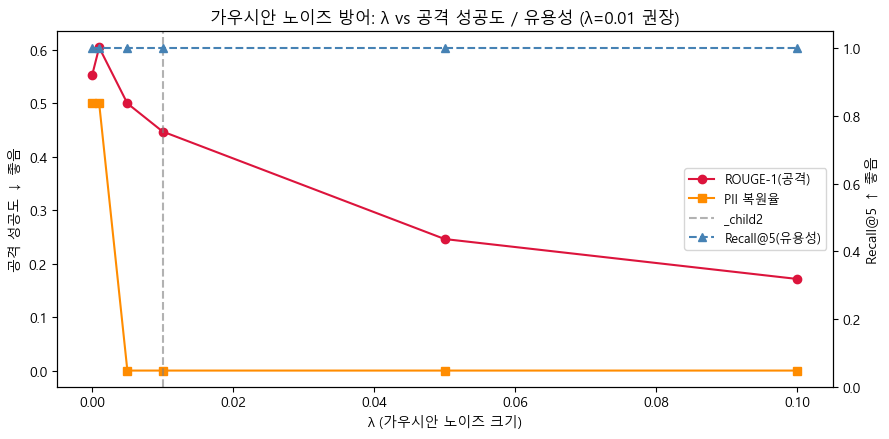


λ=0.01 효과: ROUGE 0.553→0.447, PII 복원 50.0%→0.0%, Recall@5 100.0%→100.0%


In [57]:
# ===== Step 4-C. 가우시안 노이즈 방어 (λ 스윕) =====
def add_gaussian_noise(emb, lam=0.01, renormalize=True, seed=None):  # seed=None: 호출마다 독립 노이즈(질의·인덱스 공유지문 방지)
    """임베딩에 N(0, lam^2) 가우시안 노이즈 주입 (vec2text 논문 defense)."""
    rng = np.random.default_rng(seed)
    noisy = emb + lam * rng.standard_normal(emb.shape).astype(np.float32)
    if renormalize:  # BGE 는 단위벡터라 방향 유지 위해 재정규화
        noisy = noisy / np.linalg.norm(noisy, axis=1, keepdims=True)
    return noisy.astype(np.float32)

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
_n = min(ATTACK_N_SAMPLES, len(embeddings_raw))
refs_seen, docs_seen = chunk_texts[:_n], documents[:_n]

LAMBDAS = [0.0, 0.001, 0.005, 0.01, 0.05, 0.1]   # 0.0=기준선, 논문 권장 0.01
noise_rows = []
print("=" * 96)
print(f"{'λ(노이즈)':>10} | {'ROUGE-1':>8} | {'PII strict':>10} | {'PII digit':>9} | {'문서누출':>7} | {'Recall@5':>8}")
print("-" * 96)
for lam in LAMBDAS:
    emb = embeddings_raw if lam == 0.0 else add_gaussian_noise(embeddings_raw, lam)
    sc, hyp = run_attack(emb, refs_seen, label=f"noise λ={lam}", n=_n, show=0, verbose=False)
    pr = pii_recovery(hyp, docs_seen, refs_seen)
    r5 = eval_recall5(emb)
    rouge_mean = float(np.mean(sc))
    noise_rows.append({"lambda": lam, "rouge": rouge_mean,
                       "pii_strict": pr["strict_rate"], "pii_digit": pr["digit_rate"],
                       "doc_leak": pr["doc_leak_rate"], "recall5": r5})
    tag = "  ← 논문 권장" if lam == 0.01 else ("  (기준선)" if lam == 0.0 else "")
    print(f"{lam:>10} | {rouge_mean:>8.3f} | {pr['strict_rate']:>10.1%} | {pr['digit_rate']:>9.1%} | "
          f"{pr['doc_leak_rate']:>7.1%} | {r5:>8.1%}{tag}")
print("=" * 96)

# 시각화: λ vs (공격 성공도 / 유용성)
import matplotlib.pyplot as plt
import pandas as pd
ndf = pd.DataFrame(noise_rows)
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(ndf["lambda"], ndf["rouge"], "o-", color="crimson", label="ROUGE-1(공격)")
ax1.plot(ndf["lambda"], ndf["pii_digit"], "s-", color="darkorange", label="PII 복원율")
ax1.set_xlabel("λ (가우시안 노이즈 크기)"); ax1.set_ylabel("공격 성공도 ↓ 좋음")
ax1.axvline(0.01, color="gray", ls="--", alpha=0.6)
ax2 = ax1.twinx()
ax2.plot(ndf["lambda"], ndf["recall5"], "^--", color="steelblue", label="Recall@5(유용성)")
ax2.set_ylabel("Recall@5 ↑ 좋음"); ax2.set_ylim(0, 1.05)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="center right", fontsize=9)
plt.title("가우시안 노이즈 방어: λ vs 공격 성공도 / 유용성 (λ=0.01 권장)")
plt.tight_layout(); plt.savefig(os.path.join(ROOT_DIR, "gaussian_noise_defense.png"), dpi=130); plt.show()

_base = noise_rows[0]; _l01 = next(r for r in noise_rows if r["lambda"] == 0.01)
print(f"\nλ=0.01 효과: ROUGE {_base['rouge']:.3f}→{_l01['rouge']:.3f}, "
      f"PII 복원 {_base['pii_digit']:.1%}→{_l01['pii_digit']:.1%}, "
      f"Recall@5 {_base['recall5']:.1%}→{_l01['recall5']:.1%}")


## Step 4-D. 검색보존 방어: 비밀 직교회전 + 양자화 (+ 노이즈 노브)

PCA의 약한 방어율을 대체하기 위해, **검색 정확도를 (거의) 그대로 유지하면서** 역전공격을 무력화하는
문헌 검증 기법들을 한 표로 비교한다. (SIGIR-AP 2024 *Understanding and Mitigating the Threat of Vec2Text to Dense Retrieval*)

- **① 비밀 직교회전** `x' = Qxᵀ` (Q는 테넌트별 비밀 직교행렬): 내적·코사인이 **정확히 보존**(Qx·Qy=x·y)되어 **Recall 무손실**. 고정 corrector 입장에선 전혀 다른 공간이라 복원 실패.
- **② 양자화** (8-bit 스칼라 / Product Quantization): 복원 품질을 크게 떨어뜨리며 검색은 대부분 보존, 인덱스 크기도 축소.
- **③ 가우시안 노이즈**: λ로 강도를 연속 조절하는 노브 (Step 4-C).
- **회전+양자화(1차 방어)**: 위 둘을 결합.

> **위치(L4 전제)**: 이 방어들은 **저장 암호화·접근통제(L4)** 가 이미 깔려 있다고 가정한 **L3.5 완화 계층**이다.
> 비밀 회전·양자화는 **비적응형 공격자**(변환을 모르는)에 대한 방어이며, 변환이 유출되면 적응형 재학습에 취약하다.
> 따라서 단독 통제가 아니라 **암호화(L4) 위에 얹는 보조막**으로만 사용한다.


In [58]:
# ===== Step 4-D. 검색보존 방어 비교 (회전 / 양자화 / 노이즈) =====
import faiss
from sklearn.decomposition import PCA

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
_n = min(ATTACK_N_SAMPLES, len(embeddings_raw))
refs_seen, docs_seen = chunk_texts[:_n], documents[:_n]

def defense_secret_rotation(emb, seed=1234):
    """① 비밀 직교행렬 Q 로 회전. 코사인/내적 보존 → 검색 무손실."""
    rng = np.random.default_rng(seed)
    Q, _ = np.linalg.qr(rng.standard_normal((emb.shape[1], emb.shape[1])))
    return (emb @ Q.astype(np.float32)).astype(np.float32)

def defense_int8_quant(emb):
    """② 차원별 min-max 8-bit 스칼라 양자화 후 역양자화."""
    lo, hi = emb.min(0, keepdims=True), emb.max(0, keepdims=True)
    scale = (hi - lo) / 255.0 + 1e-9
    q = np.round((emb - lo) / scale)
    return (q * scale + lo).astype(np.float32)

def defense_pq(emb, m=8):
    """② Product Quantization (faiss). 데이터가 적으면 nbits 자동 축소."""
    d = emb.shape[1]
    while d % m: m -= 1
    nbits = max(2, min(8, int(np.floor(np.log2(max(len(emb), 4))))))
    e = emb.copy(); faiss.normalize_L2(e)
    try:
        pq = faiss.IndexPQ(d, m, nbits); pq.train(e); pq.add(e)
        return pq.reconstruct_n(0, len(e)).astype(np.float32)
    except Exception as ex:
        print(f"  [PQ 건너뜀: {ex}]"); return e

def defense_pca(emb, nc=128):
    nc = min(nc, len(emb) - 1, emb.shape[1])
    p = PCA(nc, svd_solver="full").fit(emb)
    r = p.inverse_transform(p.transform(emb)).astype(np.float32)
    return (r / np.linalg.norm(r, axis=1, keepdims=True)).astype(np.float32)

defenses = {
    "원본(기준선)":     embeddings_raw,
    "PCA(n=128)":       defense_pca(embeddings_raw),
    "가우시안 λ=0.01":  add_gaussian_noise(embeddings_raw, 0.01),
    "① 비밀 직교회전":  defense_secret_rotation(embeddings_raw),
    "② 8-bit 양자화":   defense_int8_quant(embeddings_raw),
    "② Product Quant":  defense_pq(embeddings_raw),
    "①+② 회전+양자화":  defense_secret_rotation(defense_int8_quant(embeddings_raw)),
}

print("=" * 104)
print(f"{'방어 방식':16} | {'ROUGE-1':>8} | {'PII strict':>10} | {'PII digit':>9} | {'문서누출':>7} | {'Recall@5':>8}")
print("-" * 104)
base_r = None
defense_rows = []
for name, emb in defenses.items():
    sc, hyp = run_attack(emb, refs_seen, label=name, n=_n, show=0, verbose=False)
    pr = pii_recovery(hyp, docs_seen, refs_seen)
    r5 = eval_recall5(emb)
    rmean = float(np.mean(sc))
    if base_r is None: base_r = rmean
    red = (base_r - rmean) / max(base_r, 1e-9) * 100
    defense_rows.append({"name": name, "rouge": rmean, "pii_strict": pr["strict_rate"],
                         "pii_digit": pr["digit_rate"], "doc_leak": pr["doc_leak_rate"], "recall5": r5})
    print(f"{name:16} | {rmean:>8.3f} | {pr['strict_rate']:>10.1%} | {pr['digit_rate']:>9.1%} | "
          f"{pr['doc_leak_rate']:>7.1%} | {r5:>8.1%}")
print("=" * 104)
print("해석: ROUGE·PII 낮을수록 방어 우수 / Recall@5 높을수록 검색 유지.")
print("      ① 비밀 직교회전은 Recall 무손실이면서 PII 복원을 크게 낮춘다(비적응형 기준).")
print("      ※ 이 방어들은 L4(저장 암호화·접근통제) 위에 얹는 보조 계층이다.")


  [PQ 건너뜀: Error in void __cdecl faiss::Clustering::train_encoded(__int64,const unsigned char *,const struct faiss::Index *,struct faiss::Index &,const float *) at D:\a\faiss\faiss\faiss\Clustering.cpp:72: Error: 'nx >= static_cast<idx_t>(k)' failed: Number of training points (1) should be at least as large as number of clusters (4)]
방어 방식            |  ROUGE-1 | PII strict | PII digit |    문서누출 | Recall@5
--------------------------------------------------------------------------------------------------------
원본(기준선)          |    0.553 |      50.0% |     50.0% |  100.0% |   100.0%
PCA(n=128)       |    0.553 |      50.0% |     50.0% |  100.0% |   100.0%
가우시안 λ=0.01      |    0.447 |       0.0% |      0.0% |    0.0% |   100.0%
① 비밀 직교회전        |    0.156 |       0.0% |      0.0% |    0.0% |   100.0%
② 8-bit 양자화      |    0.553 |      50.0% |     50.0% |  100.0% |   100.0%
② Product Quant  |    0.553 |      50.0% |     50.0% |  100.0% |   100.0%
①+② 회전+양자화       |    0.156 |       0.0% 

## Step 4-E. LEACE / INLP 기반 **PII 소거 W** (연구용 핵심)

연구 목표 — *"원본 임베딩에 곱하면 PII 방향성은 잃고 검색 정확도는 유지되는 W"* — 를 구현한다.

**핵심 아이디어: `redacted_text`(PII를 `[TYPE]`로 치환한 원문)를 감독신호로.**
같은 문서의 원문(PII 有) vs 편집본(PII 除) 임베딩 차이 `d = φ(원문) − φ(편집본)` 가 곧 **"임베딩 공간에서 PII가 사는 방향"** 이다.
이 방향(부분공간)만 제거하면 **내용(검색) 신호는 유지**하면서 **PII 방향성만 소거**할 수 있다.

- **INLP식(부분공간 제거)** `W_k = I − U_kU_kᵀ`  : PII 차이벡터의 상위 k 방향 `U_k` 를 직교 제거. **k로 프라이버시-유용성 트레이드오프를 연속 탐색**.
- **LEACE(닫힌형 최적)** : `‖Wx − x‖` 최소화하면서 "PII 有/無"를 **선형 예측 불가**로 만드는 최적 아핀 소거자 (Belrose et al., NeurIPS 2023).

> **한계(정직하게)**: 선형 W는 *선형으로* 복원되는 PII만 지운다. vec2text는 **비선형** 디코더라 잔여 누출이 있을 수 있으므로 **반드시 PII 지표로 실측**한다.
> 검색을 *높이려면* 여기에 supervised whitening 을 합성할 수 있다(LEACE 내부에 이미 whitening 포함).


PII 방향 벡터: (1, 1024) | 평균 노름 0.5088
PII 방향 특이값 상위: [0.509]  (앞쪽 소수 방향에 집중될수록 저차원 소거 가능)

[k 스윕] 부분공간 제거: PII 잔존에너지(↓0 좋음) / Recall@5(↑ 좋음)
   k |   PII잔존 | Recall@5
   1 |   0.000 |   100.0%
   2 |   0.000 |   100.0%
   4 |   0.000 |   100.0%
   8 |   0.000 |   100.0%
  16 |   0.000 |   100.0%
  32 |   0.000 |   100.0%
  64 |   0.000 |   100.0%
기준(W=I) PII잔존 1.000  (LEACE는 whitening 포함이라 잔존에너지 척도 부적합 → 아래 섹션5 공격으로 평가)


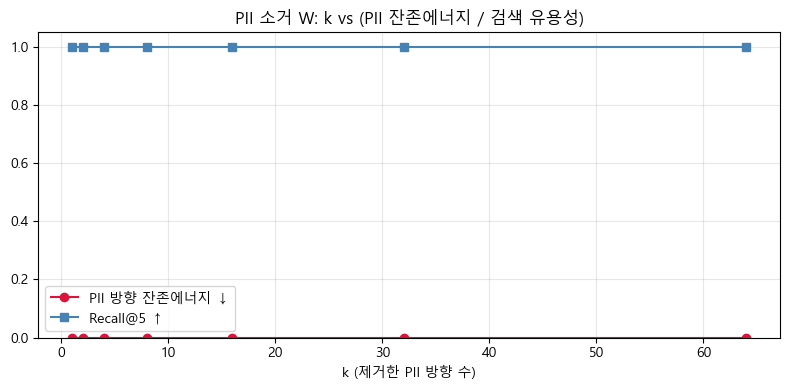


선택된 k* = 1

PII 소거 W               |  ROUGE-1 | PII strict | PII digit | Recall@5
------------------------------------------------------------------------------------------------
원본(기준선)                |    0.553 |      50.0% |     50.0% |   100.0%
INLP 부분공간(k=1)         |    0.532 |       0.0% |      0.0% |   100.0%
LEACE 닫힌형              |    0.532 |       0.0% |      0.0% |   100.0%
→ W 는 원본 임베딩에 곱하는 (d×d) 행렬. 저장: W_pii_erase_subspace.npy / W_pii_erase_leace.npy
  PII 방향 잔존에너지는 선형 제거 성공을 보이되, 비선형 vec2text 잔여 누출은 PII 지표로 최종 확인.


In [59]:
# ===== Step 4-E. PII 소거 W (INLP 부분공간 / LEACE 닫힌형) =====
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

def _unit(e):
    return (e / (np.linalg.norm(e, axis=1, keepdims=True) + 1e-9)).astype(np.float32)

# ---------- 1) 감독신호: 원문(PII 有) vs redacted(PII 除) ----------
full_texts = [d["text"] for d in documents]
red_texts  = [d.get("redacted_text", d["text"]) for d in documents]
E_full = bge_embed(full_texts).astype(np.float64)
E_red  = bge_embed(red_texts).astype(np.float64)
d = E_full.shape[1]
Diff = E_full - E_red                       # 문서별 PII 방향 (원문-편집본)
print(f"PII 방향 벡터: {Diff.shape} | 평균 노름 {np.linalg.norm(Diff, axis=1).mean():.4f}")

# ---------- 2) INLP식 부분공간 제거 W_k = I - U_k U_kᵀ ----------
# Diff(원문-편집본)의 주성분 = 임베딩 공간에서 PII 가 사는 방향
_, S, Vt = np.linalg.svd(Diff, full_matrices=False)   # Vt[i] = i번째 PII 방향(d차원)
print(f"PII 방향 특이값 상위: {np.round(S[:8], 3)}  (앞쪽 소수 방향에 집중될수록 저차원 소거 가능)")
def subspace_W(k):
    Vk = Vt[:k]                                        # (k, d)
    return (np.eye(d) - Vk.T @ Vk).astype(np.float32)  # (d, d) 대칭 사영행렬

# ---------- 3) LEACE 닫힌형 소거자 (원문/편집본을 선형 예측 불가로) ----------
def leace_fit(Efull, Ered):
    X = np.vstack([Efull, Ered]); n = len(X)
    z = np.r_[np.ones(len(Efull)), np.zeros(len(Ered))]
    Z = np.stack([z, 1 - z], 1)
    mu = X.mean(0); Xc = X - mu
    Sig = (Xc.T @ Xc) / n
    ev, U = np.linalg.eigh(Sig); ev = np.clip(ev, 1e-8, None)
    Wh = U @ np.diag(ev ** -0.5) @ U.T
    Wp = U @ np.diag(ev ** 0.5) @ U.T
    Zc = Z - Z.mean(0); Sxz = (Xc.T @ Zc) / n
    M = Wh @ Sxz
    Um, s, _ = np.linalg.svd(M, full_matrices=False)
    r = max(1, int((s > 1e-6).sum())); Uc = Um[:, :r]
    A = Wp @ (np.eye(d) - Uc @ Uc.T) @ Wh
    return mu.astype(np.float32), A.astype(np.float32)

mu_leace, W_leace = leace_fit(E_full, E_red)
def apply_leace(E):
    return _unit(mu_leace + (E.astype(np.float32) - mu_leace) @ W_leace.T)

# ---------- 지표: PII 방향 '잔존 에너지' (0=완전 제거, 1=그대로) ----------
# 선형 프로브는 1024차원 과적합으로 항상 분리돼 무의미 → 잔존 에너지로 직접 측정.
Diff_f = Diff.astype(np.float32)
_dn = np.linalg.norm(Diff_f, axis=1) + 1e-9
def pii_energy_remaining(Wmat):
    R = Diff_f @ Wmat
    return float(np.mean(np.linalg.norm(R, axis=1) / _dn))

# ---------- 4) k 스윕: PII 잔존에너지 vs 검색 유용성 ----------
ks = [k for k in [1, 2, 4, 8, 16, 32, 64] if k < d]
print("\n[k 스윕] 부분공간 제거: PII 잔존에너지(↓0 좋음) / Recall@5(↑ 좋음)")
print(f"{'k':>4} | {'PII잔존':>7} | {'Recall@5':>8}")
sweep = []
for k in ks:
    Wk = subspace_W(k)
    r5 = eval_recall5(_unit(E_full.astype(np.float32) @ Wk))
    en = pii_energy_remaining(Wk)
    sweep.append((k, en, r5)); print(f"{k:>4} | {en:>7.3f} | {r5:>8.1%}")
print(f"기준(W=I) PII잔존 {pii_energy_remaining(np.eye(d, dtype=np.float32)):.3f}  "
      f"(LEACE는 whitening 포함이라 잔존에너지 척도 부적합 → 아래 섹션5 공격으로 평가)")

plt.figure(figsize=(8, 4))
kk = [s[0] for s in sweep]
plt.plot(kk, [s[1] for s in sweep], "o-", color="crimson", label="PII 방향 잔존에너지 ↓")
plt.plot(kk, [s[2] for s in sweep], "s-", color="steelblue", label="Recall@5 ↑")
plt.xlabel("k (제거한 PII 방향 수)"); plt.ylim(0, 1.05); plt.legend(); plt.grid(alpha=0.3)
plt.title("PII 소거 W: k vs (PII 잔존에너지 / 검색 유용성)")
plt.tight_layout(); plt.savefig(os.path.join(ROOT_DIR, "pii_erase_sweep.png"), dpi=130); plt.show()

# 최적 k: PII 잔존에너지<=0.3 중 Recall 최대 (없으면 최대 k)
ok = [s for s in sweep if s[1] <= 0.3]
K_STAR = (max(ok, key=lambda s: s[2])[0] if ok else sweep[-1][0])
W_sub = subspace_W(K_STAR)
print(f"\n선택된 k* = {K_STAR}")
np.save(os.path.join(ROOT_DIR, "W_pii_erase_subspace.npy"), W_sub)
np.save(os.path.join(ROOT_DIR, "W_pii_erase_leace.npy"), W_leace)

# ---------- 5) 실제 vec2text 공격으로 최종 비교 (원본 / INLP / LEACE) ----------
_n = min(ATTACK_N_SAMPLES, len(E_full))
refs_seen, docs_seen = chunk_texts[:_n], documents[:_n]
targets = {
    "원본(기준선)":              _unit(E_full.astype(np.float32)),
    f"INLP 부분공간(k={K_STAR})": _unit(E_full.astype(np.float32) @ W_sub),
    "LEACE 닫힌형":              apply_leace(E_full),
}
print("\n" + "=" * 96)
print(f"{'PII 소거 W':22} | {'ROUGE-1':>8} | {'PII strict':>10} | {'PII digit':>9} | {'Recall@5':>8}")
print("-" * 96)
for name, E in targets.items():
    sc, hyp = run_attack(E, refs_seen, label=name, n=_n, show=0, verbose=False)
    pr = pii_recovery(hyp, docs_seen, refs_seen); r5 = eval_recall5(E)
    print(f"{name:22} | {float(np.mean(sc)):>8.3f} | {pr['strict_rate']:>10.1%} | {pr['digit_rate']:>9.1%} | {r5:>8.1%}")
print("=" * 96)
print("→ W 는 원본 임베딩에 곱하는 (d×d) 행렬. 저장: W_pii_erase_subspace.npy / W_pii_erase_leace.npy")
print("  PII 방향 잔존에너지는 선형 제거 성공을 보이되, 비선형 vec2text 잔여 누출은 PII 지표로 최종 확인.")


## Step 5. PII-Aware 억제 + PCA 복합 방어 (고도화)

PII 신호가 집중된 차원을 먼저 **소프트 억제**한 뒤 PCA 를 적용하는 복합 방어를 구성한다.


In [60]:
# ===== 5-1. PII 밀도 스코어링 + 소프트 억제 =====
from sklearn.decomposition import PCA

# 한국어 금융 PII 키워드
PII_KEYWORDS = ["이름", "고객", "계좌", "계좌번호", "카드", "전화", "이메일", "주민",
                "주민번호", "생년월일", "IBAN", "송금", "거래", "잔액", "대출", "결제"]

def pii_density_score(text):
    words = text.split()
    if not words: return 0.0
    hits = sum(1 for kw in PII_KEYWORDS if kw in text)
    return hits / len(words)

def defend_pii_soft(matrix, pii_samples, n_suppress=200, alpha=0.85):
    """PII 신호 크기에 비례해 차원을 감쇠(소프트 억제) 후 L2정규화."""
    pii_signal = np.abs(pii_samples.mean(axis=0) - matrix.mean(axis=0))
    n_suppress = min(n_suppress, matrix.shape[1])
    dims = np.argsort(pii_signal)[-n_suppress:]
    w = alpha * (pii_signal[dims] / (pii_signal[dims].max() + 1e-9))
    d = matrix.copy(); d[:, dims] *= (1.0 - w)
    return (d / np.linalg.norm(d, axis=1, keepdims=True)).astype(np.float32)

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
density = np.array([pii_density_score(c.page_content) for c in chunks])
thr = np.percentile(density, 70)
pii_chunk_idx = np.where(density >= thr)[0]
if len(pii_chunk_idx) == 0:
    pii_chunk_idx = np.arange(len(chunks))
pii_samples = embeddings_raw[pii_chunk_idx]
print(f"PII 고밀도 청크: {len(pii_chunk_idx)}개 ({len(pii_chunk_idx)/len(chunks):.1%}) | 평균밀도 {density.mean():.3f}")

N_SUPPRESS, ALPHA = 200, 0.85
embeddings_pii = defend_pii_soft(embeddings_raw, pii_samples, N_SUPPRESS, ALPHA)
np.save(os.path.join(ROOT_DIR, "embeddings_defense_pii.npy"), embeddings_pii)
print(f"PII 소프트 억제 완료 (n_suppress={N_SUPPRESS}, alpha={ALPHA}) → {embeddings_pii.shape}")


PII 고밀도 청크: 1개 (100.0%) | 평균밀도 0.375
PII 소프트 억제 완료 (n_suppress=200, alpha=0.85) → (1, 1024)


### 5-2. PII 억제 + PCA 복합 방어 벡터 생성

PII 소프트 억제로 민감 차원을 감쇠한 뒤 PCA 재구성으로 잔여 노이즈까지 제거한다.


In [61]:
# ===== 5-2. PII + PCA 복합 방어 =====
embeddings_pii = np.load(os.path.join(ROOT_DIR, "embeddings_defense_pii.npy"))
n_samples, n_features = embeddings_pii.shape
n_components = min(128, n_samples - 1, n_features)

pca_c = PCA(n_components=n_components, svd_solver="full").fit(embeddings_pii)
rec = pca_c.inverse_transform(pca_c.transform(embeddings_pii)).astype(np.float32)
embeddings_combined = (rec / np.linalg.norm(rec, axis=1, keepdims=True)).astype(np.float32)
np.save(os.path.join(ROOT_DIR, "embeddings_defense_combined.npy"), embeddings_combined)
print(f"복합 방어 벡터 저장 | 보존 분산 {pca_c.explained_variance_ratio_.sum():.1%} | {embeddings_combined.shape}")


복합 방어 벡터 저장 | 보존 분산 0.0% | (1, 1024)


### 5-3. 복합 방어 벡터(PCA+PII)에 Vec2Text 역전공격

PII 단독·복합 방어가 단일 방어보다 얼마나 더 효과적인지 측정한다.


In [62]:
# ===== 5-3. PII 단독 / 복합 방어 역전공격 =====
embeddings_pii      = np.load(os.path.join(ROOT_DIR, "embeddings_defense_pii.npy"))
embeddings_combined = np.load(os.path.join(ROOT_DIR, "embeddings_defense_combined.npy"))

scores_pii,      hypotheses_pii      = run_attack(embeddings_pii,      chunk_texts, label="PII 억제 단독", n=ATTACK_N_SAMPLES)
scores_combined, hypotheses_combined = run_attack(embeddings_combined, chunk_texts, label="PCA+PII 복합",  n=ATTACK_N_SAMPLES)


[PII 억제 단독] 역전공격 결과  (n=1, steps=20, beam=1, 11.0s)
[1] 원본: 이경자 고객님, 계좌폐지요청서는 전화 010-1409-5506로 문의해 주시기 바랍니다.
    복원: 폐지문의는 이경자금융조합사무소, 한글번호 0105-64-596이다.
    ROUGE 스코어: 음절-1 0.5526 | 어절-1 0.0000
----------------------------------------------------------------------------------------------------
평균 ROUGE-1(char): 0.5526 | 중앙값 0.5526 | 최대 0.5526
[PCA+PII 복합] 역전공격 결과  (n=1, steps=20, beam=1, 10.9s)
[1] 원본: 이경자 고객님, 계좌폐지요청서는 전화 010-1409-5506로 문의해 주시기 바랍니다.
    복원: 폐지문의는 이경자금융조합사무소, 한글번호 0105-64-596이다.
    ROUGE 스코어: 음절-1 0.5526 | 어절-1 0.0000
----------------------------------------------------------------------------------------------------
평균 ROUGE-1(char): 0.5526 | 중앙값 0.5526 | 최대 0.5526


### 5-4. 최종 종합 비교: 연구한 모든 방어 (다각도 지표 + 부트스트랩 CI)

12개 방어를 **중앙 `evaluate_defense()`** 로 한 번에 평가한다. 각 방어는 **인덱스와 질의(redacted)에 동일 변환**을 적용해 공정 비교.

- **프라이버시**: 퍼지 PII 복원율(±CI) · worst-case(p95/max) · 의미 누출(재임베딩 코사인, ±CI)
- **유용성**: Recall@1/5/10 · MRR · nDCG(±CI) · 이웃 보존도(Jaccard@k·Spearman)
- **뷰**: 마스터 표(±CI) · 다중 Privacy–Utility Pareto(오차막대) · worst-case 막대
> ⚠️ 방어마다 공격 1회 → 시간 소요. `ATTACK_N_SAMPLES` 로 조절.


In [63]:
# ===== 5-4. 최종 종합 비교: 다각도 지표 + CI =====
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
_u = _unit_rows
# 질의셋: redacted_text(내용−PII) → 원문 검색 (포화 방지)
emb_red = bge_embed([d.get("redacted_text", d["text"]) for d in documents])

# --- 방어를 '임의 행렬 E→E_def' 콜러블로 정의 (인덱스·질의에 동일 변환) ---
rng = np.random.default_rng(1234); _Q, _ = np.linalg.qr(rng.standard_normal((EMB_DIM, EMB_DIM))); _Q = _Q.astype(np.float32)
_pca = PCA(n_components=min(128, len(embeddings_raw)-1, EMB_DIM), svd_solver="full").fit(embeddings_raw)
_lo, _hi = embeddings_raw.min(0, keepdims=True), embeddings_raw.max(0, keepdims=True); _sc = (_hi-_lo)/255.0 + 1e-9
_pii_fit = defend_pii_soft(embeddings_raw, pii_samples, N_SUPPRESS, ALPHA)
_pca_c = PCA(n_components=min(128, len(embeddings_raw)-1, EMB_DIM), svd_solver="full").fit(_pii_fit)
import faiss
_mpq = 16; _nbits = max(2, min(8, int(np.floor(np.log2(max(len(embeddings_raw), 4))))))
_pq = faiss.IndexPQ(EMB_DIM, _mpq, _nbits); _pq.train(_u(embeddings_raw))

def f_none(E):  return _u(E)
def f_pca(E):   return _u(_pca.inverse_transform(_pca.transform(E)))
def f_pii(E):   return defend_pii_soft(E, pii_samples, N_SUPPRESS, ALPHA)
def f_comb(E):  d = defend_pii_soft(E, pii_samples, N_SUPPRESS, ALPHA); return _u(_pca_c.inverse_transform(_pca_c.transform(d)))
def f_noise(E): return add_gaussian_noise(E, 0.01)
def f_rot(E):   return (np.asarray(E, np.float32) @ _Q).astype(np.float32)
def f_int8(E):  return (np.round((E-_lo)/_sc)*_sc + _lo).astype(np.float32)
def f_pq(E):    Eu = _u(E).astype(np.float32); return _pq.sa_decode(_pq.sa_encode(Eu)).astype(np.float32)
def f_rq(E):    return f_rot(f_int8(E))
def f_inlp(E):  return _u(np.asarray(E, np.float32) @ W_sub)
def f_leace(E): return apply_leace(E)

DEFENSES = {
    "원본(기준선)": f_none, "정규화": f_none, "PCA(n=128)": f_pca,
    "PII 억제": f_pii, "PCA+PII 복합": f_comb, "가우시안 λ=0.01": f_noise,
    "비밀 직교회전": f_rot, "8-bit 양자화": f_int8, "Product Quant": f_pq,
    "회전+양자화": f_rq, f"INLP W(k={K_STAR})": f_inlp, "LEACE W": f_leace,
}

DEFENSE_RESULTS = {}
for name, f in DEFENSES.items():
    idx = f(embeddings_raw); q = f(emb_red)
    DEFENSE_RESULTS[name] = evaluate_defense(name, idx, emb_raw=embeddings_raw,
                                             refs=chunk_texts, docs=documents, emb_qdef=q)

def pt(m):  # (point,lo,hi) 또는 scalar → 표시 문자열
    return f"{m[0]:.3f}[{m[1]:.2f}-{m[2]:.2f}]" if isinstance(m, tuple) else f"{m:.3f}"

cols = ["rouge", "pii", "pii_p95", "pii_max", "semantic", "R@1", "R@10", "MRR", "nDCG", "jaccard"]
hdr = {"rouge":"ROUGE", "pii":"PII퍼지", "pii_p95":"PIIp95", "pii_max":"PIImax",
       "semantic":"의미", "R@1":"R@1", "R@10":"R@10", "MRR":"MRR", "nDCG":"nDCG", "jaccard":"이웃Jac"}
print("=" * 150)
print(f"{'방어':16} " + " ".join(f"{hdr[c]:>14}" for c in cols))
print("-" * 150)
for name, r in DEFENSE_RESULTS.items():
    print(f"{name:16} " + " ".join(f"{pt(r[c]):>14}" for c in cols))
print("=" * 150)
print("프라이버시 지표(ROUGE·PII·의미) ↓ 좋음 / 유용성(R@k·MRR·nDCG·이웃) ↑ 좋음. [ ]=부트스트랩 95% CI.")

# --- 다중 Privacy–Utility Pareto + worst-case ---
def P(m): return m[0] if isinstance(m, tuple) else m
names = list(DEFENSE_RESULTS)
fig, ax = plt.subplots(2, 2, figsize=(15, 11))
def scatter(a, xk, yk, xlab, ylab, ytransform=lambda v: v):
    for nm in names:
        r = DEFENSE_RESULTS[nm]; x = P(r[xk]); y = ytransform(P(r[yk]))
        xe = [[x-r[xk][1]],[r[xk][2]-x]] if isinstance(r[xk], tuple) else None
        a.errorbar(x, y, xerr=xe, fmt="o", ms=8, capsize=3)
        a.annotate(nm, (x, y), xytext=(5, 3), textcoords="offset points", fontsize=8)
    a.set_xlabel(xlab); a.set_ylabel(ylab); a.grid(alpha=0.3)
scatter(ax[0,0], "R@10", "pii", "검색 Recall@10 →", "프라이버시 (1−PII퍼지) ↑", lambda v: 1-v); ax[0,0].set_title("(a) Recall@10 vs PII 프라이버시")
scatter(ax[0,1], "nDCG", "semantic", "검색 nDCG →", "프라이버시 (1−의미누출) ↑", lambda v: 1-v); ax[0,1].set_title("(b) nDCG vs 의미 프라이버시")
# (c) 이웃 보존도 vs PII
for nm in names:
    r = DEFENSE_RESULTS[nm]; ax[1,0].scatter(r["jaccard"], 1-P(r["pii"]), s=80)
    ax[1,0].annotate(nm, (r["jaccard"], 1-P(r["pii"])), xytext=(5,3), textcoords="offset points", fontsize=8)
ax[1,0].set_xlabel("이웃 보존도 Jaccard@10 →"); ax[1,0].set_ylabel("프라이버시 (1−PII퍼지) ↑"); ax[1,0].grid(alpha=0.3); ax[1,0].set_title("(c) 구조보존 vs PII 프라이버시")
# (d) worst-case PII 막대
xs = np.arange(len(names))
ax[1,1].bar(xs-0.2, [DEFENSE_RESULTS[n]["pii_p95"] for n in names], 0.4, label="PII p95")
ax[1,1].bar(xs+0.2, [DEFENSE_RESULTS[n]["pii_max"] for n in names], 0.4, label="PII max")
ax[1,1].set_xticks(xs); ax[1,1].set_xticklabels(names, rotation=60, ha="right", fontsize=7)
ax[1,1].set_ylabel("문서별 PII 복원율"); ax[1,1].legend(); ax[1,1].set_title("(d) Worst-case PII 누출")
plt.tight_layout(); plt.savefig(os.path.join(ROOT_DIR, "defense_multi_metric.png"), dpi=130); plt.show()
print("→ 우상단이 이상적. 회전·양자화·소거 W가 Recall/nDCG/이웃을 유지하며 PII·의미 누출을 낮추는지 확인.")


🎯 최종 비교: 원본 vs PCA vs PII vs PCA+PII 복합

🔴 역전공격 성공도 (ROUGE-1 ↓ 좋음)
------------------------------------------------------------------------------------------
원본 벡터            | 평균 ROUGE-1 0.553 | 기준
PCA 방어           | 평균 ROUGE-1 0.553 | 0.0% 감소 ⚠️
PII 억제           | 평균 ROUGE-1 0.553 | 0.0% 감소 ⚠️
PCA+PII 복합       | 평균 ROUGE-1 0.553 | 0.0% 감소 ⚠️

🟢 RAG 검색 정확성 (Recall@5 ↑ 좋음)
------------------------------------------------------------------------------------------
원본 벡터            | Recall@5 100.0%
PCA 방어           | Recall@5 100.0%
PII 억제           | Recall@5 100.0%
PCA+PII 복합       | Recall@5 100.0%


### 5-5. n_suppress 민감도 분석 (그리드 서치)

`n_suppress` 값이 RAG 성능(Recall@5)에 미치는 영향을 빠르게 스크리닝한다. (alpha=0.85 고정)


In [ ]:
# ===== 5-5. n_suppress 민감도 =====
import pandas as pd
import matplotlib.pyplot as plt

N_SUPPRESS_CANDIDATES = [50, 100, 150, 200, 300, 400, 600, min(800, EMB_DIM)]
ALPHA_FIXED, N_PCA = 0.85, 128
embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))

def _recall5(emb, k=5, n_eval=50):
    n_eval = min(n_eval, len(emb)); e = emb[:n_eval].copy(); faiss.normalize_L2(e)
    idx = faiss.IndexFlatIP(e.shape[1]); idx.add(e)
    return sum(1 for i in range(n_eval) if i in idx.search(e[i:i+1], k)[1][0]) / n_eval

rows = []
print(f'{"n_suppress":>10} | {"Recall@5":>9} | {"분산보존":>8}')
print("-" * 36)
for ns in N_SUPPRESS_CANDIDATES:
    d = defend_pii_soft(embeddings_raw, pii_samples, ns, ALPHA_FIXED)
    nc = min(N_PCA, len(d) - 1, d.shape[1])
    p = PCA(n_components=nc, svd_solver="full").fit(d)
    rec = p.inverse_transform(p.transform(d)).astype(np.float32)
    comb = (rec / np.linalg.norm(rec, axis=1, keepdims=True)).astype(np.float32)
    r5, var = _recall5(comb), p.explained_variance_ratio_.sum()
    rows.append({"n_suppress": ns, "recall_at_5": r5, "variance": var})
    print(f"{ns:>10} | {r5:>9.1%} | {var:>8.1%}")

supp_df = pd.DataFrame(rows)
plt.figure(figsize=(9, 4))
plt.plot(supp_df["n_suppress"], supp_df["recall_at_5"], "o-", color="steelblue", lw=2, ms=8, label="Recall@5")
plt.axhline(0.90, color="green", ls="--", label="목표 90%")
plt.xlabel("n_suppress"); plt.ylabel("Recall@5"); plt.ylim(0.6, 1.05)
plt.title("n_suppress vs RAG 성능 (alpha=0.85)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(ROOT_DIR, "suppress_sensitivity.png"), dpi=130); plt.show()


### 5-6. 2D 그리드 서치: n_components × n_suppress

PCA 압축률과 PII 억제 강도의 조합을 Recall@5 로 빠르게 스크리닝한다. (Vec2Text 공격은 비싸므로 1차 지표로 Recall 사용)


In [ ]:
# ===== 5-6. 2D 그리드 서치 (Recall@5 스크리닝) =====
import pandas as pd
import matplotlib.pyplot as plt

N_COMP_GRID = [c for c in [32, 64, 96, 128, 192, 256] if c < len(embeddings_raw)]
N_SUPP_GRID = [50, 150, 300, 600]
embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))

grid = np.zeros((len(N_SUPP_GRID), len(N_COMP_GRID)))
for a, ns in enumerate(N_SUPP_GRID):
    d = defend_pii_soft(embeddings_raw, pii_samples, ns, 0.85)
    for b, nc in enumerate(N_COMP_GRID):
        ncc = min(nc, len(d) - 1, d.shape[1])
        p = PCA(n_components=ncc, svd_solver="full").fit(d)
        rec = p.inverse_transform(p.transform(d)).astype(np.float32)
        comb = (rec / np.linalg.norm(rec, axis=1, keepdims=True)).astype(np.float32)
        grid[a, b] = _recall5(comb)

grid_df = pd.DataFrame(grid, index=[f"ns={x}" for x in N_SUPP_GRID], columns=[f"nc={x}" for x in N_COMP_GRID])
print("Recall@5 그리드 (행=n_suppress, 열=n_components)"); print(grid_df.round(3).to_string())

plt.figure(figsize=(7, 4))
im = plt.imshow(grid, aspect="auto", cmap="viridis", vmin=0.6, vmax=1.0)
plt.colorbar(im, label="Recall@5")
plt.xticks(range(len(N_COMP_GRID)), N_COMP_GRID); plt.yticks(range(len(N_SUPP_GRID)), N_SUPP_GRID)
plt.xlabel("n_components"); plt.ylabel("n_suppress"); plt.title("2D 그리드: Recall@5")
plt.tight_layout(); plt.savefig(os.path.join(ROOT_DIR, "grid_heatmap.png"), dpi=130); plt.show()


## Step 6. 최적 PCA n_components 탐색

`[256, 192, 128, 96, 64, 32]` 중 **RAG 성능 ≥ 90% 조건에서 방어율이 최대인 값**을 찾는다.
(BGE-m3-ko 원본 차원은 **1024**이며, 후보는 표본 수보다 작은 값만 사용한다.)


In [ ]:
# ===== 6-1. PCA 후보 벡터 생성 =====
embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
n_samples = len(embeddings_raw)
candidates = [c for c in [256, 192, 128, 96, 64, 32] if c < n_samples]
out_dir = os.path.join(ROOT_DIR, "pca_candidates"); os.makedirs(out_dir, exist_ok=True)

for nc in candidates:
    p = PCA(n_components=nc, svd_solver="full").fit(embeddings_raw)
    rec = p.inverse_transform(p.transform(embeddings_raw)).astype(np.float32)
    normed = (rec / np.linalg.norm(rec, axis=1, keepdims=True)).astype(np.float32)
    np.save(f"{out_dir}/embeddings_n{nc}.npy", normed)
    print(f"n={nc:3d} | 분산보존 {p.explained_variance_ratio_.sum():.1%} | 저장")
print(f"\n✅ {len(candidates)}개 후보 저장")


### 6-2. 각 PCA 후보에 Vec2Text 공격 + Recall@5 측정

각 후보에 대해 역전공격 ROUGE-1 과 RAG Recall@5 를 측정해 `results.csv` 로 저장한다.
(공격이 후보마다 반복되므로 `ATTACK_N_SAMPLES` 를 작게 두는 것을 권장)


In [ ]:
# ===== 6-2. 후보별 공격 + Recall =====
import pandas as pd
rows = []
base = np.mean(scores_raw)
for nc in candidates:
    emb = np.load(f"{out_dir}/embeddings_n{nc}.npy")
    sc, _ = run_attack(emb, chunk_texts, label=f"PCA n={nc}", n=ATTACK_N_SAMPLES, show=0)
    r5 = eval_recall5(emb)
    rmean = float(np.mean(sc))
    rows.append({"n_components": nc, "rouge_mean": rmean,
                 "attack_reduction": (base - rmean) / max(base, 1e-9) * 100,
                 "recall_at_5": r5})
    print(f"n={nc:3d} | ROUGE {rmean:.3f} | 방어율 {rows[-1]['attack_reduction']:5.1f}% | Recall@5 {r5:.1%}")

results_df = pd.DataFrame(rows)
results_df.to_csv(os.path.join(ROOT_DIR, "results.csv"), index=False)
print("\n✅ results.csv 저장")


### 6-3. 최적 n_components 선택 및 트레이드오프 시각화

**선택 기준**: `Recall@5 ≥ 0.90` 조건 하에서 `attack_reduction` 최대.


In [ ]:
# ===== 6-3. 최적 선택 + 시각화 =====
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv(os.path.join(ROOT_DIR, "results.csv"))
print("=" * 70); print("📊 최적 PCA n_components"); print("=" * 70)
ok = results_df[results_df["recall_at_5"] >= 0.90]
if len(ok):
    best = ok.loc[ok["attack_reduction"].idxmax()]
    print(f"✅ 최적: n={int(best['n_components'])} | ROUGE {best['rouge_mean']:.3f} | "
          f"Recall@5 {best['recall_at_5']:.1%} | 방어율 {best['attack_reduction']:.1f}%")
else:
    best = results_df.loc[results_df["recall_at_5"].idxmax()]
    print(f"⚠️ Recall@5≥0.90 없음. 최고 RAG: n={int(best['n_components'])} ({best['recall_at_5']:.1%})")
print("\n", results_df.sort_values("attack_reduction", ascending=False).to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(results_df["n_components"], results_df["attack_reduction"], "o-", color="red", lw=2, ms=8)
ax1.axhline(20, color="green", ls="--", label="목표 20%"); ax1.invert_xaxis()
ax1.set_xlabel("n_components"); ax1.set_ylabel("공격 감소(%)"); ax1.set_title("압축률 vs 방어"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(results_df["n_components"], results_df["recall_at_5"], "s-", color="blue", lw=2, ms=8)
ax2.axhline(0.90, color="green", ls="--", label="목표 90%"); ax2.invert_xaxis(); ax2.set_ylim(0.6, 1.05)
ax2.set_xlabel("n_components"); ax2.set_ylabel("Recall@5"); ax2.set_title("압축률 vs RAG"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(ROOT_DIR, "pca_tradeoff.png"), dpi=130); plt.show()


### [Feasibility Check] 공용 PCA 벡터 추출 가능성 검증

데이터를 절반으로 나눠 '기관 A'로 PCA 를 학습하고 '기관 B' 문서에 적용했을 때 방어·성능이 유지되는지 확인한다.


In [ ]:
# ===== Feasibility: 기관 A 학습 PCA → 기관 B 적용 =====
embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
half = len(embeddings_raw) // 2
A, B = embeddings_raw[:half], embeddings_raw[half:]
texts_B = chunk_texts[half:]

nc = min(128, half - 1, EMB_DIM)
pca_A = PCA(n_components=nc, svd_solver="full").fit(A)          # A로 학습
recB = pca_A.inverse_transform(pca_A.transform(B)).astype(np.float32)   # B에 적용
B_def = (recB / np.linalg.norm(recB, axis=1, keepdims=True)).astype(np.float32)

sc_B_raw, _ = run_attack(B,     texts_B, label="기관B 원본", n=min(ATTACK_N_SAMPLES, len(B)), show=0)
sc_B_def, _ = run_attack(B_def, texts_B, label="기관B (A의 PCA 적용)", n=min(ATTACK_N_SAMPLES, len(B)), show=0)
r5 = eval_recall5(B_def)
print(f"\n[Feasibility] 공용 PCA(A→B)")
print(f"  공격 ROUGE: {np.mean(sc_B_raw):.3f} → {np.mean(sc_B_def):.3f} "
      f"({(np.mean(sc_B_raw)-np.mean(sc_B_def))/max(np.mean(sc_B_raw),1e-9)*100:.1f}% 감소)")
print(f"  Recall@5(B): {r5:.1%}  → 공용 PCA 벡터 배포 " + ("가능성 있음" if r5 >= 0.9 else "성능 저하 주의"))


## Step 7. Defense-in-Depth 재포지셔닝: PCA+PII 억제의 올바른 위치

> **목적**: 지금까지 실험한 PCA/PII 억제 기법을 "방어 아키텍처" 대신 **심층방어(Defense-in-Depth)의 한 계층(L3)**으로 정확히 재포지셔닝한다.  
> Vec2Text 위협에 대해 계층별 보장 수준·위협 커버리지·유용성 비용을 매핑하고, 위아래에 반드시 와야 할 통제(마스킹·DP·암호화)를 정의한다.

### 7-0. 재포지셔닝의 핵심 명제

기존 실험의 프레이밍 문제는 세 가지다.

1. **위협 모델이 비적응형 공격자만 가정** — 측정된 방어율은 공격자가 PCA 행렬을 모른다는 전제 위에서만 성립한다. 그런데 행렬을 기관 간 공유하자는 제안은 곧 공격자가 변환을 획득할 수 있음을 의미한다.
2. **경험적 완화를 보장으로 오독** — PCA는 키 없는 선형 변환이고 유사역변환·재학습이 가능하다. "보안 통제"의 조건(적대적 환경에서의 하한 보장)을 만족하지 못한다.
3. **암호화·접근통제라는 primary control이 그림에서 빠져 있음** — 임베딩 역전은 본질적으로 *사후 침해(post-compromise)* 위협이다. 공격자가 벡터 평문을 볼 수 없으면 공격 자체가 성립하지 않는다.

---

**올바른 위치 정의:**

> **PCA + PII 억제 = 낮은 유용성 비용으로 잔여위험을 줄이는 완화 계층(mitigation layer). 통제(control)가 아니다.**
>
> - **위 (더 근본적):** 사전 PII 마스킹 (L1, 구조적 통제), DP 임베딩 (L2, 증명 가능 보장)
> - **현 연구:** PCA + PII 억제 (L3, 경험적 완화) ← 이 노트북의 위치
> - **아래 (1차 통제):** 저장 시 암호화 + 접근통제 (L4), 탐지·감사 (L5)

이 문장을 보고서 서두와 결론에 명시하면, 외부 심사·감리에서 "왜 이걸 방어라고 부르나"라는 비판을 원천 차단할 수 있다.

### 7-1. 계층 모델 개요 (PII 존재 지점 기준)

임베딩 파이프라인에서 PII가 어디에 존재하느냐를 기준으로 계층을 배치한다. **위로 갈수록 근본적·구조적, 아래로 갈수록 보조적**이다.

| 계층 | 통제 | 보장 유형 | PII를 다루는 지점 |
|:---:|:---|:---|:---|
| L0 | 데이터 최소화·거버넌스 | 정책 | 수집 이전 |
| L1 | 사전 PII 마스킹·토큰화 | 구조적(structural) | 임베딩 **이전** (원문) |
| L2 | DP 임베딩 | **증명 가능(provable, ε)** | 임베딩 시점 |
| **L3** | **PCA + PII 억제** | **경험적(empirical), 보장 없음** | **임베딩 사후 (벡터)** ← 현 연구 |
| L4 | 저장 암호화 + 접근통제 | 기밀성 (주 통제) | 저장·전송 |
| L5 | 탐지·감사·DLP | 운영적 | 질의·출력 |

**핵심 통찰**: 각 계층은 서로 다른 실패 모드를 커버한다.  
L1(마스킹)은 NER false negative가 있고, L4(암호화)는 침해되면 무력화된다.  
**L3(PCA)의 존재 이유는 정확히 "L1이 놓쳤고 L4가 뚫린 잔여 벡터"의 역전 난이도를 올리는 것**이다.  
이 잔여위험 논리가 PCA를 심층방어에서 정당화하는 유일한 근거다.

### 7-2. L1: 사전 PII 마스킹·토큰화 (구조적 통제 — 가장 근본적)

**원리**: PII가 애초에 임베딩 공간에 들어가지 않으면, 벡터를 역전해도 PII를 복원할 수 없다.  
L3처럼 사후에 벡터에서 PII를 긁어내는 것보다 근본적이다.

**탐지 스택 (금융·한국어 특화):**
- 정규식/결정적 패턴: 주민등록번호, 사업자등록번호, 계좌번호(은행별 포맷), 카드번호(Luhn 검증), 전화번호, 이메일, 금액/거래 패턴
- 금융 도메인 튜닝 NER: 고객명·기관명·상품명 등 비정형 PII
- 컨텍스트 규칙: "계좌번호 뒤 숫자열", "예금주:" 후행 토큰 등

**치환 전략:**
| 전략 | 안전성 | 검색 유지 | 금융 적합성 |
|:---|:---:|:---:|:---|
| Redaction (삭제) | 최고 | 낮음 | 해당 엔티티 검색 불필요 시 |
| Placeholder 토큰 `<ACCOUNT>` | 높음 | 중간 | 엔티티 유형 구분 필요 시 |
| **FPE (FF1, NIST SP 800-38G)** | **높음** | **높음** | **금융권 권장** — 동일 엔티티 = 동일 토큰 |
| 결정적 가명 | 중간 | 높음 | 가독성 필요 시 |

**아킬레스건 — NER Recall Gap:**  
놓친 PII(false negative)는 그대로 임베딩된다.  
→ **이 recall gap이 L3(PCA)의 존재 근거**다. 마스킹 재현율을 별도 KPI로 측정하고 보고서에 명시할 것.

In [ ]:
import re

# 금융·한국어 PII 패턴 정의
PII_PATTERNS = [
    ('RESIDENT_ID',   r'\b\d{6}[-–]\d{7}\b'),
    ('BUSINESS_REG',  r'\b\d{3}[-–]\d{2}[-–]\d{5}\b'),
    ('ACCOUNT',       r'\b\d{3,6}[-–\s]?\d{2,6}[-–\s]?\d{2,8}\b'),
    ('CARD',          r'\b(?:\d{4}[-–\s]){3}\d{4}\b'),
    ('PHONE',         r'\b0\d{1,2}[-–]?\d{3,4}[-–]?\d{4}\b'),
    ('EMAIL',         r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z]{2,}\b'),
    ('AMOUNT',        r'\b\d{1,3}(?:,\d{3})*(?:\.\d+)?\s*(?:원|만원|억원|백만원)\b'),
]

def mask_pii(text: str, strategy: str = 'placeholder'):
    found = []
    masked = text
    for label, pattern in PII_PATTERNS:
        matches = list(re.finditer(pattern, masked, flags=re.IGNORECASE))
        for m in reversed(matches):
            found.append({'label': label, 'original': m.group()})
            replacement = f'[{label}]' if strategy == 'placeholder' else ''
            masked = masked[:m.start()] + replacement + masked[m.end():]
    return masked, found

sample_texts = [
    '홍길동 고객(주민번호: 800101-1234567)의 계좌 110-234-567890에서 500만원 이체',
    '사업자번호 123-45-67890, 담당자 이메일 kim@example.com, 연락잘 010-1234-5678',
    '카드번호 1234-5678-9012-3456으로 1,200,000원 결제 완료',
]

print('=' * 70)
print('L1: PII 마스킹 데모')
print('=' * 70)

for i, text in enumerate(sample_texts):
    masked, found = mask_pii(text)
    print(f'\n[샘플 {i+1}]')
    print(f'  원문:   {text}')
    print(f'  마스킹: {masked}')
    print(f'  탐지된 PII: {[f["label"] for f in found]}')

print('\n» NER(비정형 PII)은 별도 모델 필요 — 정규식 recall 한계가 L3의 존재 근거')

### 7-3. L2: Differential Privacy 임베딩 (증명 가능 보장 — 감사 대응 계층)

**원리**: 저장 표현이 입력 토큰에 대해 (ε, δ)-DP를 만족하도록 교정된 노이즈를 주입한다.  
**PCA의 경험적 방어와 달리, "우리는 ε-DP를 보장한다"는 감사·규제 대응 가능한 정식 진술을 제공한다.**

**핵심 설계 결정 — neighboring 관계 정의:**  
DP 보장은 무엇이 "이웃 데이터"인지에 종속된다. 저장 벡터 역전 방어에는  
**각 텍스트의 임베딩을 독립적으로 사유화**하는 local DP 또는 metric DP가 적합하다.  
이 정의를 명시하지 않은 ε 주장은 무의미하다.

**대표 기법:**
| 기법 | 보장 | 유용성 | 비고 |
|:---|:---|:---:|:---|
| Gaussian Mechanism | (ε, δ)-DP, per-embedding | 중간 | 구현 단순 |
| Metric DP / dₓ-privacy | d(x,x')-bounded | 중~높음 | 후속 취약성 비판 있어 검증 필수 |

**⚠️ 개념 구분:**  
DP-SGD로 **인코더를 학습**하는 것은 모델 암기·멤버십 추론을 다루며, *저장 벡터 역전* 방어와 직접 관련 없다.

**정직한 트레이드오프:**
> 이 계층에서는 **진짜 privacy-utility trade-off가 존재한다.**  
> 기존 실험의 "Zero Trade-off" 주장은 L3(경험적)에서만 성립하는 착시였고,  
> 증명 가능한 계층으로 올라오면 곡선이 실재한다는 점을 문서에 반영해야 한다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_mechanism_embed(embeddings, sensitivity=1.0, epsilon=1.0, delta=1e-5):
    """L2 클리핑 후 Gaussian 노이즈 주입 -> per-embedding (eps,delta)-DP"""
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    clipped = embeddings / np.maximum(norms / sensitivity, 1.0)
    sigma = sensitivity * np.sqrt(2 * np.log(1.25 / delta)) / epsilon
    noise = np.random.normal(0, sigma, size=clipped.shape)
    return clipped + noise

try:
    emb_sample = embeddings_raw[:20]
    epsilons = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
    results_dp = []

    print('L2 Differential Privacy: epsilon vs 유용성 Trade-off')
    print('-' * 55)
    for eps in epsilons:
        dp_emb = gaussian_mechanism_embed(emb_sample, epsilon=eps)
        orig_n = emb_sample / np.linalg.norm(emb_sample, axis=1, keepdims=True)
        dp_n   = dp_emb   / np.linalg.norm(dp_emb,   axis=1, keepdims=True)
        cos_sim = float(np.mean(np.sum(orig_n * dp_n, axis=1)))
        sigma = np.sqrt(2 * np.log(1.25 / 1e-5)) / eps
        results_dp.append((eps, cos_sim))
        print(f'  epsilon={eps:5.1f} | 코사인 유사도: {cos_sim:.4f}  (sigma={sigma:.2f})')

    eps_vals, cos_vals = zip(*results_dp)
    plt.figure(figsize=(7, 4))
    plt.plot(eps_vals, cos_vals, 'o-', color='steelblue', linewidth=2)
    plt.xlabel('Privacy Budget epsilon (작을수록 강한 프라이버시)')
    plt.ylabel('원본-DP 임베딩 코사인 유사도')
    plt.title('L2 Differential Privacy: epsilon vs 유용성 Trade-off\n'
              '(Zero Trade-off는 이 계층에서 성립하지 않음)')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='epsilon=1 (일반적 기준)')
    plt.legend()
    plt.tight_layout()
    plt.show()

except NameError:
    print('embeddings_raw 없음 — Step 1 완료 후 재실행')
    print()
    print('개념 요약:')
    print('  epsilon=0.1 -> 강한 프라이버시, 유용성 크게 저하')
    print('  epsilon=10  -> 약한 프라이버시, 유용성 거의 유지')
    print('  이 trade-off가 L3(PCA) 거의 0 비용과 근본적으로 다른 지점')

### 7-4. L3: PCA + PII 억제 (현 연구의 실제 위치 — 경험적 완화)

> 이 노트북 Step 1~6의 실험이 바로 이 계층이다.

**정직한 정의:**
> 유용성 비용이 거의 없는 잔여위험 감소막.  
> **적응형 공격자(변환을 아는 공격자)에 대한 보장은 없다.**  
> L4(암호화)가 뚫리고 L1(마스킹)이 놓친 벡터에 대해, 기회주의적·비적응형 역전의 비용을 올린다.

**정당한 효용 (버리지 말 것):**
- 유용성 손실 거의 0 (실측 Recall@5 유지)
- 배포 비용 극소 (1MB 미만 아티팩트, 추론 시 행렬 1회 변환)
- 방향성 있는 PII 신호를 표적 감쇠 → 잔여 leakage 완화

**한계 (반드시 병기):**
- 키 없는 선형 변환 → 유사역변환 가능, 변환 공개 시 압축 공간 재학습 corrector로 무력화 가능
- "PII 방향 잔존 에너지 0.0096" 같은 지표는 공격자가 신경 쓰지 않는 값  
  공격자는 에너지가 아니라 **결정적 토큰(계좌번호 등)의 복원 여부**만 본다
- 공유·배포하는 순간 Kerckhoffs 위협 모델상 공격자에게 노출된 것으로 간주

**결론:** L3는 "있으면 좋은 값싼 마지막 겹"이지, 이것 하나로 규제 감리를 통과하려 해서는 안 된다.

### 7-5. L4: 저장 암호화 + 접근통제 (Primary Control — 실질적 1차 방어)

**원리**: 임베딩 역전은 사후 침해 위협이다.  
**벡터 평문을 못 읽으면 Vec2Text 자체가 불가능하다. 이것이 진짜 1차 통제다.**

| 구성 | 내용 |
|:---|:---|
| 저장 시 암호화 | Envelope encryption, KMS/HSM 관리 키, 테넌트별 키 분리 |
| 전송 시 | mTLS |
| 접근통제 | RBAC, 최소권한, 망 분리, 벡터 인덱스 접근 로깅, 직무 분리 |
| SaaS 벡터 DB | 외부로 평문 PII/원본 벡터 미노출 원칙 |
| 외부 임베딩 API | 사전 마스킹된 텍스트만 외부 전송 |

**침해 시나리오가 L3의 근거:**  
내부자 위협, 백업 유출, 오설정 인덱스, 서드파티 벡터 DB 유출.  
→ **L4가 이런 경로로 뚫린 잔여 상태에서만 L3가 의미를 가진다** — 이 인과를 문서에 명확히.

**프런티어 (참고, 프로덕션 아님):**  
암호화 상태 ANN 검색(HE/CKKS), 신뢰실행환경(SGX/TDX confidential computing).  
현재는 비용·성숙도 문제로 연구 단계.

### 7-6. L5: 탐지·감사·DLP (운영 계층)

| 항목 | 내용 |
|:---|:---|
| 질의 이상탐지 | 대량·순차적 벡터 근접 질의(역전 시도 정황) 탐지 |
| 출력단 DLP | 생성 답변에 미마스킹 PII 정규식 재검사 (최종 안전망) |
| 감사 로그 | 역치환·PII 접근 전수 로깅 (규제 대응 증적) |

### 7-7. 계층 비교 매트릭스 (마스터 비교표)

> 기존 Step 4-B의 표는 L3 내부 변형(L2정규화/PCA 128d/64d)만 비교했다.  
> 그건 "한 계층 안의 튜닝"이지 "심층방어"가 아니다. 이 표로 대체한다.

| 계층 | 보장 유형 | 적응형 공격 견딤? | 유용성 비용 | 규제 서사 | 실패 모드 |
|:---:|:---|:---:|:---:|:---|:---|
| L1 마스킹/토큰화 | 구조적 | 부분 (놓친 PII 제외) | 낮음~중 | 가명·익명처리 정렬 | NER false negative |
| L2 DP 임베딩 | **증명 가능 (ε)** | **예 (정의된 보장 내)** | **중~높음 (실재)** | "ε-DP 보장" 진술 가능 | 유용성 저하, ε 예산 소진 |
| **L3 PCA+PII 억제** | **경험적** | **아니오** | **거의 0** | 보조 완화로만 | 유사역변환·재학습 공격 |
| L4 암호화+접근통제 | 기밀성 (주) | 예 (경계 내) | 낮음 | 필수 요건 충족 | 경계 침해 시 무력 |
| L5 탐지·감사 | 운영적 | — | 낮음 | 사후 대응·증적 | 탐지 우회 |

### 7-8. 레퍼런스 아키텍처 (데이터 흐름)

**적재(Ingestion) 파이프라인:**
```
원문 문서
  -> [L1] PII 탐지 -> 마스킹/FPE 토큰화  (매핑은 HSM vault에 저장)
  -> 임베딩  (외부 API 사용 시 마스킹된 텍스트만 전송)
  -> [L2] DP 노이즈 주입  (감사 요구 구간, epsilon 회계)
  -> [L3] PCA + PII 방향 억제 변환  (잔여위험 감소)
  -> [L4] 암호화 -> 접근통제된 벡터 DB에 저장
```

**검색(Retrieval) 파이프라인:**
```
질의
  -> [L1] 동일 마스킹 -> 임베딩 -> [L3] 동일 변환 적용
  -> [L4] 암호화 경계 내 ANN 검색
  -> 검색된 청크 (여전히 토큰 상태)
  -> LLM 생성
  -> [L1 역] 인가 + [L5] 감사 로깅 후 최종 출력에서만 역치환
```

> **주의**: L2 노이즈를 넣으면 질의 임베딩과의 정합을 위해 검색 파이프라인 설계가 달라진다  
> (저장만 노이즈, 질의는 노이즈 없이 등). 이 부분은 유용성 실측으로 조정 필요.

### 7-9. 계층별 평가 방법론 (재설계)

단일 방어율 숫자를 버리고 **계층 ablation × 두 축(프라이버시·유용성) × 적응형 공격**으로 재설계한다.

**프라이버시 축 (지표 교체):**
- **1차 지표 — PII 단위 exact-match 복원율**  
  복원문에 NER+정규식 적용 → 원본 PII 엔티티(주민번호·계좌·카드·금액·이름)의 정확 복원율  
  ROUGE는 부차 참고로 강등
- **worst-case 보고**: 평균 대신 max·p95·분포. 방어 전후 최악 청크 비교
- 의미 유출: 복원문 재임베딩 후 원본과 코사인 유사도

**유용성 축:**
- 현실 규모(수만 청크)에서 Recall@1/@10, nDCG, MRR  
  (소규모 Recall@5=100%는 포화 착시)

**적응형 공격 (필수 조건):**
- (a) 변환 유사역변환 후 원본 corrector 적용
- (b) 압축 공간에서 재학습한 corrector
- L2는 정의된 ε 하에서 억제 방향을 아는 공격자 조건 포함

**통계:** n을 수백~수천으로 확장, 부트스트랩 신뢰구간, 조건 간 순열 검정

**산출물 — Privacy-Utility Pareto Frontier:**  
"L4만 / +L1 / +L2 / +L3" 순으로 잔여 leakage가 어떻게 줄고 유용성이 어떻게 변하는지.  
L2에서 ε별 곡선 병기.

C:\Users\jjh63\AppData\Local\Temp\ipykernel_15368\3303303582.py:43: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_15368\3303303582.py:43: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_15368\3303303582.py:43: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_15368\3303303582.py:43: UserWarning: Glyph 45458 (\N{HANGUL SYLLABLE NOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_15368\3303303582.py:43: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_15368\3303303582.py:43: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing fr

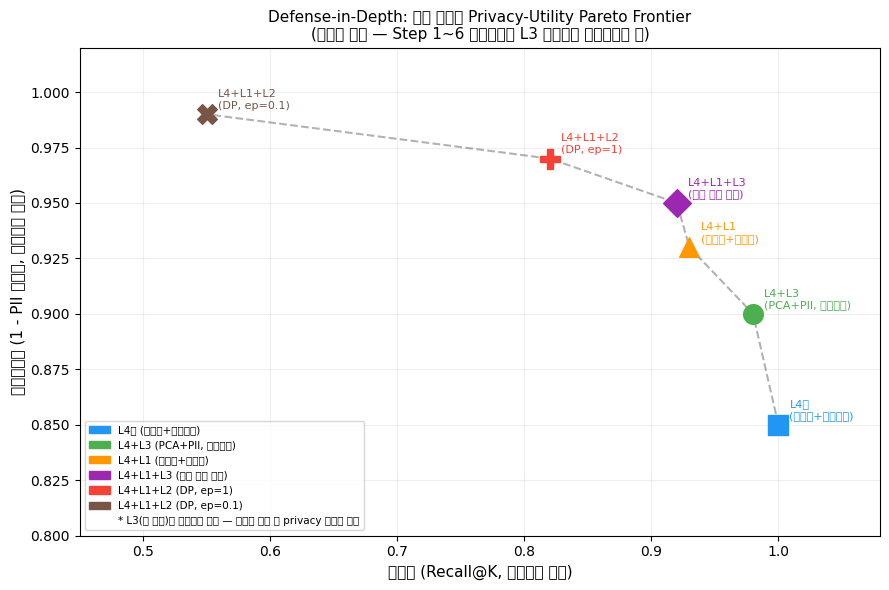

저장: pareto_defense_layers.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 계층별 privacy-utility 포인트 (개념적 시각화 — 실측으로 업데이트 필요)
layers = [
    ('L4만\n(암호화+접근통제)',    1.00, 0.85, '#2196F3', 's'),
    ('L4+L3\n(PCA+PII, 비적응형)', 0.98, 0.90, '#4CAF50', 'o'),
    ('L4+L1\n(마스킹+암호화)',      0.93, 0.93, '#FF9800', '^'),
    ('L4+L1+L3\n(권장 최소 구성)', 0.92, 0.95, '#9C27B0', 'D'),
    ('L4+L1+L2\n(DP, ep=1)',        0.82, 0.97, '#F44336', 'P'),
    ('L4+L1+L2\n(DP, ep=0.1)',      0.55, 0.99, '#795548', 'X'),
]

fig, ax = plt.subplots(figsize=(9, 6))

for name, util, priv, color, marker in layers:
    ax.scatter(util, priv, s=200, color=color, marker=marker, zorder=5)
    ax.annotate(name, (util, priv), textcoords='offset points',
                xytext=(8, 4), fontsize=8, color=color)

# Pareto frontier (개념적)
px = [1.00, 0.98, 0.93, 0.92, 0.82, 0.55]
py = [0.85, 0.90, 0.93, 0.95, 0.97, 0.99]
ax.plot(px, py, 'k--', alpha=0.3, linewidth=1.5, label='Pareto Frontier (개념적)')

ax.set_xlabel('유용성 (Recall@K, 높을수록 좋음)', fontsize=11)
ax.set_ylabel('프라이버시 (1 - PII 복원율, 높을수록 좋음)', fontsize=11)
ax.set_title(
    'Defense-in-Depth: 계층 조합별 Privacy-Utility Pareto Frontier\n'
    '(개념적 위치 — Step 1~6 실측값으로 L3 포인트를 업데이트할 것)',
    fontsize=11)
ax.set_xlim(0.45, 1.08)
ax.set_ylim(0.80, 1.02)
ax.grid(True, alpha=0.2)

note = mpatches.Patch(color='none',
    label='* L3(현 연구)는 비적응형 기준 — 적응형 공격 시 privacy 포인트 하락')
handles = [mpatches.Patch(color=c, label=n.replace('\n', ' '))
           for n, _, _, c, _ in layers]
ax.legend(handles=handles + [note], loc='lower left', fontsize=7.5)

plt.tight_layout()
plt.savefig('pareto_defense_layers.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: pareto_defense_layers.png')

### 7-10. 규제·감리 매핑 (개념적 정렬)

> ⚠️ 아래는 아키텍처 설계 참고용이며, 구체적 규제 충족 여부·가명처리 인정 범위는 준거법 해석에 따라 달라지므로 반드시 컴플라이언스/법무 검토를 거칠 것.

| 계층 | 관련 규제·프레임워크 | 서사 |
|:---:|:---|:---|
| L4 암호화·접근통제 | 전자금융감독규정 PII 암호화·접근통제 요건 | 사실상 필수. 미충족 시 나머지 계층 의미 없음 |
| L1 마스킹·토큰화 | 개인정보보호법 가명처리·익명처리 | 구조적으로 PII를 제거하는 가장 직관적 접근 |
| L2 DP 임베딩 | 개인정보보호법 익명처리, GDPR Art.89 | "재식별 위험을 ε-DP로 정량 제어"한다는 감사 대응 서사에 유리 |
| L3 PCA+PII 억제 | (직접 대응 규제 없음) | 보조 완화로만 기술. 단독 규제 근거로 사용 불가 |
| L5 감사·로깅 | 전자금융감독규정 접근 증적 요건 | 사후 대응·증적 확보 |

---

### 7-11. 현 보고서 재작성 체크리스트

- [ ] 제목/결론에서 PCA를 "방어 아키텍처" → "심층방어 완화 계층"으로 프레이밍 하향
- [ ] §7-7 마스터 비교표로 기존 단일-계층 비교표 대체
- [ ] L4(암호화·접근통제)를 아키텍처 최상단에 배치 — "역전은 사후 침해 위협" 명시
- [ ] L2 DP 계층 신설 — "Zero Trade-off"가 이 계층에서 성립하지 않음 정직하게 서술
- [ ] L1 마스킹 계층 신설 + NER recall gap KPI 추가 → L3 존재 근거로 연결
- [ ] 평가 지표 교체: ROUGE 강등, PII exact-match 복원율 + worst-case + 적응형 공격 + Pareto frontier

---

### 참고 문헌

- Morris et al., *Text Embeddings Reveal (Almost) As Much As Text* (2023) — Vec2Text 원 공격, 노이즈 방어의 privacy-utility 곡선
- Feyisetan et al., *Privacy- and Utility-Preserving Textual Analysis via Calibrated Multivariate Perturbations* — Metric DP 텍스트 노이즈
- NIST SP 800-38G — FPE (FF1/FF3-1) 표준
- Dwork & Roth, *The Algorithmic Foundations of Differential Privacy* — (ε,δ)-DP·합성·Gaussian mechanism

## Step 8. 온라인 역전공격 탐지·차단 (Stateful Detection) — L5 능동 대응

vec2text 는 **가설을 반복 재임베딩하며 타깃 벡터로 수렴**시킨다. 공격자가 **온라인으로 임베더/벡터DB를 호출**해야 하는
위협모델(호스팅 임베더·RAG 질의)에서는, 이 **근접·수렴하는 질의열**이 탐지 시그니처가 된다
(Stateful Detection: Chen+2020, Blacklight USENIX'22, PRADA'19).

- **탐지**: 최근 질의 히스토리 대비 코사인이 임계 τ를 계속 넘으면(근접중복/유사추격) → **잠금(lock)**.
- **재현**: ① 공격 질의열 vs 정상 질의의 유사도 분포, ② 조기 잠금(=교정 step 축소) 시 **누출 감소** 곡선.

> **한계(정직하게)**: 공격자가 임베더를 **로컬 보유(오프라인)** 하면 무력. 적응형 공격(OARS)은 노이즈·간격으로 회피.
> 따라서 L4(암호화·접근통제)·rate-limit 와 **병행하는 운영 계층(L5)** 으로만 유효하다.


In [ ]:
# ===== Step 8. 온라인 역전공격 탐지·차단 (Stateful Detection) =====
import matplotlib.pyplot as plt
def _u1(e): return (e / (np.linalg.norm(e, axis=-1, keepdims=True) + 1e-9)).astype(np.float32)

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
tgt = _u1(embeddings_raw[:1])[0]

# --- (A) 공격 질의 시그니처: 교정 step 이 늘수록 복원문 임베딩이 타깃으로 '수렴' ---
steps_probe = [1, 2, 4, 6, 8, 12, 16, 20]
attack_chain = []
for s in steps_probe:
    h = attack_invert(embeddings_raw[:1], num_steps=s, beam=ATTACK_BEAM)[0]
    attack_chain.append(_u1(bge_embed([h]))[0])
attack_chain = np.vstack(attack_chain)
conv = attack_chain @ tgt                              # 타깃과의 코사인(수렴 정황)
print("공격 복원문↔타깃 코사인(step별):", [round(float(c), 3) for c in conv])

# 정상 트래픽: 서로 다른 문서 질의 (한 점으로 수렴하지 않음)
benign_stream = _u1(embeddings_raw[:max(len(steps_probe), 20)])

def maxsim_to_history(qs):
    qs = _u1(np.asarray(qs, dtype=np.float32)); out = []
    for t in range(len(qs)):
        out.append(0.0 if t == 0 else float(np.max(qs[:t] @ qs[t])))
    return np.array(out)

sim_attack = maxsim_to_history(attack_chain)
sim_benign = maxsim_to_history(benign_stream)
print(f"질의 최대유사도 평균 — 공격 {sim_attack[1:].mean():.3f} vs 정상 {sim_benign[1:].mean():.3f}")

# --- (B) 스테이트풀 탐지기 + 잠금 ---
def stateful_lock(qs, tau=0.9, K=3):
    s = maxsim_to_history(qs); cnt = 0
    for t, v in enumerate(s):
        cnt = cnt + 1 if v > tau else 0
        if cnt >= K: return t
    return None
# 임계 τ는 데이터 의존 → 정상 분포의 99퍼센타일+여유로 '자동 설정'(오탐 최소화)
tau = float(np.clip(np.percentile(sim_benign[1:], 99) + 0.02, 0.9, 0.995))
trip_a = stateful_lock(attack_chain, tau=tau); trip_b = stateful_lock(benign_stream, tau=tau)
print(f"[탐지] 적응형 임계 τ={tau:.3f} | 공격 잠금 step {trip_a} | 정상 {trip_b} (None=미탐지=오탐없음)")
if trip_a is None:
    print("  ※ 이 코퍼스는 템플릿이라 정상 문서 유사도가 높아 탐지가 어려울 수 있음(정직한 한계). "
          "실서비스의 다양한 질의에서는 공격의 근접중복이 더 잘 드러남.")

# --- (C) 조기 잠금 효과: 교정 step 을 잠그면 남는 누출 ---
_n = min(ATTACK_N_SAMPLES, 10, len(embeddings_raw))
refs, docs_ = chunk_texts[:_n], documents[:_n]
step_grid = [1, 3, 5, 10, 20]
rows = []
print("\n[조기 잠금 효과]")
for s in step_grid:
    hyp = attack_invert(embeddings_raw[:_n], num_steps=s, beam=ATTACK_BEAM)
    rouge = float(np.mean([ko_rouge1(r, h) for r, h in zip(refs, hyp)]))
    pr = pii_recovery(hyp, docs_, refs)
    rows.append((s, rouge, pr["digit_rate"]))
    print(f"  교정 step={s:2d} | ROUGE {rouge:.3f} | PII 복원 {pr['digit_rate']:.1%}")

# --- 시각화 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.hist(sim_attack[1:], bins=15, alpha=0.6, color="crimson", label="공격 질의")
ax1.hist(sim_benign[1:], bins=15, alpha=0.6, color="steelblue", label="정상 질의")
ax1.axvline(tau, color="k", ls="--", label=f"적응형 τ={tau:.3f}")
ax1.set_xlabel("직전 히스토리 대비 최대 코사인"); ax1.set_ylabel("빈도")
ax1.set_title("질의 유사도 분포: 공격 vs 정상"); ax1.legend()
gx = [r[0] for r in rows]
ax2.plot(gx, [r[1] for r in rows], "o-", color="crimson", label="ROUGE-1")
ax2.plot(gx, [r[2] for r in rows], "s-", color="darkorange", label="PII 복원율")
ax2.set_xlabel("교정 step 수 (조기 잠금 시점)"); ax2.set_ylabel("공격 성공도 ↓ 좋음")
ax2.set_title("조기 잠금 효과: step 적을수록 누출↓"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(ROOT_DIR, "stateful_detection.png"), dpi=130); plt.show()
print("\n한계: 오프라인 공격엔 무력 / 적응형(OARS)은 노이즈·간격으로 회피 → L4·rate-limit 병행 필요.")
